# EDA — Dataset CSEDM / ProgSnap2 v6

Análise Exploratória de Dados para o projeto de Knowledge Tracing no CSEDM.  
Metodologia: fase de *Data Preparation* do EDM Process (Kalita et al., 2025).

---

## 1 — Estatísticas Básicas e Qualidade dos Dados

**Contexto:** Antes de qualquer modelagem, é preciso confirmar que o dataset CSEDM/ProgSnap2 foi carregado corretamente, que os splits têm as dimensões esperadas e que não há problemas críticos de qualidade (valores ausentes, duplicatas, inconsistências de Score). Esta seção estabelece os fatos de base que todo notebook subsequente assume.  
**Hipótese:** O split All deve conter ~360 mil eventos, 506 estudantes, 5 assignments e 50 problemas. O split Release/Train deve apresentar ~23.7% de tentativas corretas — benchmark de reprodutibilidade de Shi et al. (2022).  
**Referência:** Price et al. (2020); Shi et al. (2022).

### 1.1 — Composição do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_ROOT = Path('../data/CSEDM')

In [2]:
# Carregar MainTable do split All (dataset completo)
all_main = pd.read_csv(DATA_ROOT / 'All/Data/MainTable.csv')
print(f'Shape: {all_main.shape}')
all_main.head(3)

Shape: (360176, 17)


,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Run.Program,1.0,NaN,NaN,NaN,11161,11161,NaN
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Compile,NaN,Success,NaN,NaN,11162,11162,11161.0
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Run.Program,0.0,NaN,NaN,NaN,11163,11163,NaN


### 1.1.1 — Distribuição de EventTypes

**Contexto:** O ProgSnap2 define três EventTypes no CSEDM: `Run.Program` (execução com Score), `Compile` (evento filho gerado 1:1 pelo Run.Program com mesmo timestamp) e `Compile.Error` (compilação com erro, sem execução). A proporção de cada tipo determina quais eventos entram em cada modelo: BKT/DKT usam apenas `Run.Program`; Code-DKT com srcML inclui também `Compile.Error`.  
**Hipótese:** Esperamos ~35% de `Run.Program`, ~35% de `Compile` (evento filho 1:1) e ~30% de `Compile.Error`. O EventType `Submit` não existe no CSEDM — submissões são `Run.Program` com Score não-nulo.  
**Referência:** Price et al. (2020).

In [3]:
event_counts = (
    all_main['EventType']
    .value_counts()
    .rename_axis('EventType')
    .reset_index(name='Count')
)
event_counts['%'] = (event_counts['Count'] / event_counts['Count'].sum() * 100).round(2)
print(event_counts.to_string(index=False))

    EventType  Count     %
  Run.Program 125578 34.87
      Compile 125578 34.87
Compile.Error 109020 30.27


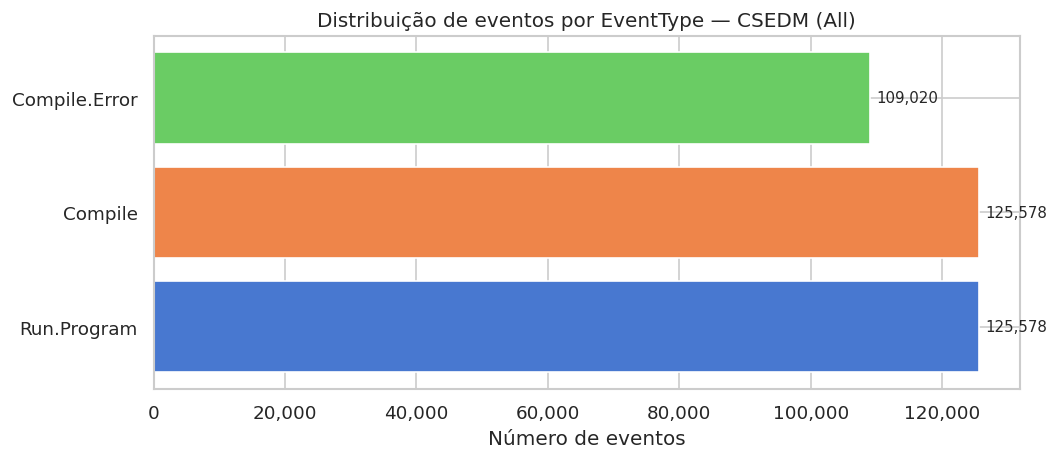

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(event_counts['EventType'], event_counts['Count'], color=sns.color_palette('muted'))
ax.bar_label(bars, labels=[f"{v:,}" for v in event_counts['Count']], padding=4, fontsize=9)
ax.set_xlabel('Número de eventos')
ax.set_title('Distribuição de eventos por EventType — CSEDM (All)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Achado:** O split All contém 360.176 eventos em três EventTypes: `Run.Program` (125.578; 34.87%), `Compile` (125.578; 34.87%) e `Compile.Error` (109.020; 30.27%). O EventType `Submit` não existe no CSEDM — confirmando a especificação ProgSnap2.  
**Implicação para modelagem:** `Compile.Error` representa 30.27% dos eventos — volume substancial que seria descartado pelo Code-DKT original (que exige código parsável). O uso de srcML (Pankiewicz, Shi & Baker, 2025) permite incluir esses eventos como `correct=0` na sequência KT, preservando informação de esforço mesmo em submissões não-compiláveis. Para BKT e DKT, filtrar por `EventType == 'Run.Program'` é suficiente.

### 1.1.2 — Entidades Únicas

**Contexto:** Confirmar o número de estudantes, assignments e problemas garante que o split correto foi carregado e que a estrutura KC=ProblemID (10 KCs por assignment) é viável para o protocolo de KT adotado.  
**Hipótese:** Esperamos 506 estudantes, 5 assignments e 50 ProblemIDs (10 por assignment) no split All — consistente com a documentação CSEDM (Fall 2019, set–dez 2019) e com os 5 assignments reportados em Shi et al. (2022).  
**Referência:** Shi et al. (2022); Price et al. (2020).

In [5]:
n_students    = all_main['SubjectID'].nunique()
n_assignments = all_main['AssignmentID'].dropna().nunique()
n_problems    = all_main['ProblemID'].dropna().nunique()
n_events      = len(all_main)

summary = pd.DataFrame({
    'Métrica': ['Total de eventos', 'Estudantes únicos (SubjectID)',
                'Assignments únicos (AssignmentID)', 'Problemas únicos (ProblemID)'],
    'Valor': [f'{n_events:,}', f'{n_students:,}', f'{n_assignments:,}', f'{n_problems:,}']
})
display(summary.set_index('Métrica'))

print('\nAssignmentIDs:', sorted(all_main['AssignmentID'].dropna().unique()))
print('ProblemIDs:   ', sorted(all_main['ProblemID'].dropna().unique()))

,Valor
Métrica,
Total de eventos,"360,176"
Estudantes únicos (SubjectID),506
Assignments únicos (AssignmentID),5
Problemas únicos (ProblemID),50



AssignmentIDs: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]
ProblemIDs:    [np.int64(1), np.int64(3), np.int64(5), np.int64(12), np.int64(13), np.int64(17), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(28), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(49), np.int64(51), np.int64(56), np.int64(57), np.int64(64), np.int64(67), np.int64(70), np.int64(71), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(106), np.int64(107), np.int64(108), np.int64(112), np.int64(118), np.int64(128), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(236)]


**Achado:** O split All contém 506 estudantes únicos, 5 assignments (IDs: 439, 487, 492, 494, 502) e 50 ProblemIDs — distribuídos uniformemente em 10 por assignment.  
**Implicação para modelagem:** A estrutura de 10 KCs por assignment confirma a viabilidade do protocolo de Shi et al. (2022): 5 modelos independentes, um por assignment, com KC=ProblemID. O input one-hot do DKT terá dimensão `2 × 10 = 20` por tentativa (problem × correctness); o Code-DKT concatena ainda o vetor de representação de código a esse input.

### 1.1.3 — Participação dos Estudantes por Assignment

**Contexto:** Verificar se todos os estudantes participaram dos 5 assignments ou se há dropout ao longo do semestre. Dropout significativo pode indicar viés de seleção nos últimos assignments e afeta a comparabilidade de desempenho entre fases do curso.  
**Hipótese:** Esperamos que a maioria dos 506 estudantes tenha participado de todos os 5 assignments, com queda progressiva menor que 10% ao longo do semestre (dropout natural de fim de curso).  
**Referência:** Shi et al. (2022).

In [6]:
students_per_assignment = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('AssignmentID')['SubjectID']
    .nunique()
    .reset_index(name='Estudantes')
    .sort_values('AssignmentID')
)
students_per_assignment['% do total'] = (
    students_per_assignment['Estudantes'] / n_students * 100
).round(1)
display(students_per_assignment)

,AssignmentID,Estudantes,% do total
0,439,500,98.8
1,487,494,97.6
2,492,494,97.6
3,494,488,96.4
4,502,478,94.5


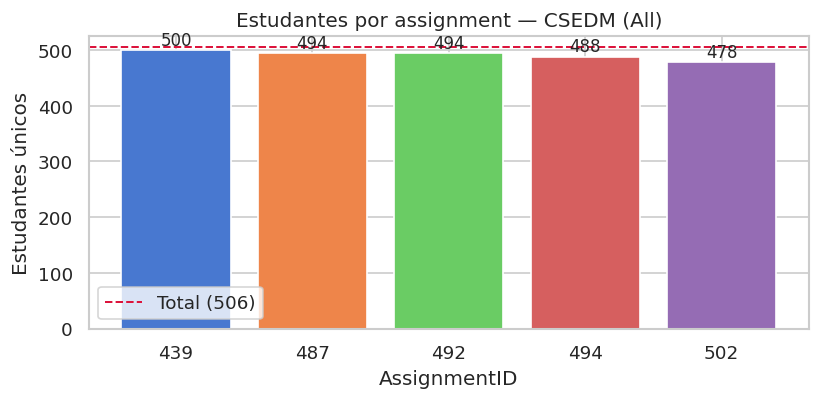

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(
    students_per_assignment['AssignmentID'].astype(str),
    students_per_assignment['Estudantes'],
    color=sns.color_palette('muted')
)
ax.axhline(n_students, color='crimson', linestyle='--', linewidth=1.2, label=f'Total ({n_students})')
for bar, val in zip(ax.patches, students_per_assignment['Estudantes']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('AssignmentID')
ax.set_ylabel('Estudantes únicos')
ax.set_title('Estudantes por assignment — CSEDM (All)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Quantos assignments cada estudante completou (participou de pelo menos 1 evento)
assignments_per_student = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('SubjectID')['AssignmentID']
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index()
)
assignments_per_student.columns = ['Nº de assignments', 'Estudantes']
assignments_per_student['%'] = (
    assignments_per_student['Estudantes'] / n_students * 100
).round(1)
display(assignments_per_student)

full_participants = assignments_per_student.loc[
    assignments_per_student['Nº de assignments'] == n_assignments, 'Estudantes'
].sum()
print(f'\nEstudantes que participaram de TODOS os {n_assignments} assignments: {full_participants} '
      f'({full_participants/n_students*100:.1f}%)')

,Nº de assignments,Estudantes,%
0,1,2,0.4
1,2,5,1.0
2,3,9,1.8
3,4,35,6.9
4,5,455,89.9



Estudantes que participaram de TODOS os 5 assignments: 455 (89.9%)


**Achado:** 89.9% dos estudantes (455/506) participaram de todos os 5 assignments. A taxa de participação caiu de 98.8% no A1 para 94.5% no A5 — dropout de ~4.3pp ao longo do semestre. Apenas 2 estudantes participaram de apenas 1 assignment.  
**Implicação para modelagem:** O dropout baixo (< 10%) não compromete o treinamento por assignment. Estudantes com participação parcial serão incluídos nos modelos dos assignments em que participaram; não é necessário excluí-los para replicar o protocolo de Shi et al. (2022).

### 1.1.4 — Consistência entre Splits

**Contexto:** O CSEDM tem dois semestres distintos — All (Fall 2019, ~506 estudantes) e Release (Spring 2019, ~329 estudantes). Confirmar que não há sobreposição de SubjectIDs entre as famílias de splits é pré-requisito para avaliação livre de data leakage.  
**Hipótese:** Release e All devem ter 0 estudantes em comum (semestres distintos). Release/Train e Release/Test devem ser mutuamente exclusivos por estudante, com ratio treino/teste próximo de 4:1.  
**Referência:** Shi et al. (2022); Price et al. (2020).

In [9]:
rel_train = pd.read_csv(DATA_ROOT / 'Release/Train/Data/MainTable.csv')
rel_test  = pd.read_csv(DATA_ROOT / 'Release/Test/Data/MainTable.csv')

splits = {
    'All':           all_main,
    'Release/Train': rel_train,
    'Release/Test':  rel_test,
}

rows = []
for name, df in splits.items():
    rows.append({
        'Split':       name,
        'Eventos':     f"{len(df):,}",
        'Estudantes':  df['SubjectID'].nunique(),
        'Assignments': df['AssignmentID'].dropna().nunique(),
        'Problemas':   df['ProblemID'].dropna().nunique(),
        'EventTypes':  df['EventType'].nunique(),
    })

display(pd.DataFrame(rows).set_index('Split'))

,Eventos,Estudantes,Assignments,Problemas,EventTypes
Split,,,,,
All,"360,176",506,5,50,3
Release/Train,"134,508",246,5,50,3
Release/Test,"32,372",83,3,30,3


In [10]:
train_students = set(rel_train['SubjectID'].unique())
test_students  = set(rel_test['SubjectID'].unique())
all_students   = set(all_main['SubjectID'].unique())
overlap        = train_students & test_students

print(f'Estudantes em Release/Train : {len(train_students)}')
print(f'Estudantes em Release/Test  : {len(test_students)}')
print(f'Sobreposição Train ∩ Test   : {len(overlap)}')
if overlap:
    print('  -> ATENÇÃO: existem estudantes em treino e teste simultaneamente.')
else:
    print('  -> OK: splits mutuamente exclusivos por estudante.')

only_in_all    = all_students - (train_students | test_students)
only_in_splits = (train_students | test_students) - all_students
print(f'\nSubjectIDs em All mas não em Release splits: {len(only_in_all)}')
print(f'SubjectIDs em Release mas não em All       : {len(only_in_splits)}')

total_release = len(train_students) + len(test_students)
print(f'\nRatio Release Train/Test (estudantes): '
      f'{len(train_students)/total_release:.0%} / {len(test_students)/total_release:.0%}')

Estudantes em Release/Train : 246
Estudantes em Release/Test  : 83
Sobreposição Train ∩ Test   : 0
  -> OK: splits mutuamente exclusivos por estudante.

SubjectIDs em All mas não em Release splits: 506
SubjectIDs em Release mas não em All       : 329

Ratio Release Train/Test (estudantes): 75% / 25%


**Achado:** Release e All têm 0 estudantes em comum — populações completamente distintas (Spring 2019 vs Fall 2019). Release/Train (246 estudantes) e Release/Test (83 estudantes) são mutuamente exclusivos; ratio Train/Test ≈ 75/25.  
**Implicação para modelagem:** A separação correta de splits garante avaliação sem data leakage. Os modelos serão treinados em Release/Train e avaliados em Release/Test, seguindo exatamente o protocolo de Shi et al. (2022). O split All é reservado para EDA e análise exploratória — não contamina o pipeline de avaliação.

---

## 1.2 — Qualidade dos Dados e Anatomia dos Splits

**Contexto:** Identificar problemas de qualidade (valores ausentes, duplicatas, inconsistências de Score) antes do pré-processamento evita surpresas durante o treinamento. Esta seção também valida qual split reproduz os números do paper Code-DKT.  
**Hipótese:** Colunas essenciais para KT (`CodeStateID`, `Score`, `EventType`) devem ter cobertura adequada nos seus respectivos EventTypes. Os 236.024 registros com mesmo (SubjectID, ProblemID, Timestamp) são pares Run.Program/Compile com mesmo timestamp — comportamento esperado do ProgSnap2, não erros de coleta.  
**Referência:** Price et al. (2020); Shi et al. (2022).

### 1.2.1 — Anatomia dos Splits: All vs Release

**Contexto:** Confirmar as datas de início/fim e número de estudantes por split valida que a separação temporal entre semestres está correta. Cada família de splits (All/Train/Test vs Release/Train/Test) deve cobrir um semestre distinto.  
**Hipótese:** All/Train/Test devem cobrir set–dez 2019 (Fall). Release/Train/Test devem cobrir fev–mai 2019 (Spring). As duas famílias devem ter 0 estudantes em comum.  
**Referência:** Price et al. (2020); Shi et al. (2022).

In [11]:
# Carregar todos os splits para comparação
train_all = pd.read_csv(DATA_ROOT / 'Train/Data/MainTable.csv')
test_all  = pd.read_csv(DATA_ROOT / 'Test/Data/MainTable.csv')

all_splits = {
    'All':           all_main,
    'Train':         train_all,
    'Test':          test_all,
    'Release/Train': rel_train,
    'Release/Test':  rel_test,
}

rows = []
for name, df in all_splits.items():
    ts = pd.to_datetime(df['ServerTimestamp'], errors='coerce')
    rows.append({
        'Split':       name,
        'Eventos':     len(df),
        'Estudantes':  df['SubjectID'].nunique(),
        'Assignments': df['AssignmentID'].dropna().nunique(),
        'Problemas':   df['ProblemID'].dropna().nunique(),
        'Data início': str(ts.min().date()) if ts.notna().any() else None,
        'Data fim':    str(ts.max().date()) if ts.notna().any() else None,
    })

display(pd.DataFrame(rows).set_index('Split'))

,Eventos,Estudantes,Assignments,Problemas,Data início,Data fim
Split,,,,,,
All,360176,506,5,50,2019-09-23,2019-12-05
Train,262398,367,5,50,2019-09-23,2019-12-05
Test,65042,123,3,30,2019-09-23,2019-10-29
Release/Train,134508,246,5,50,2019-02-20,2019-05-06
Release/Test,32372,83,3,30,2019-02-20,2019-03-25


In [12]:
# Verificar relação entre famílias de splits
family_all     = set(all_main['SubjectID']) | set(train_all['SubjectID']) | set(test_all['SubjectID'])
family_release = set(rel_train['SubjectID']) | set(rel_test['SubjectID'])

train_ids = set(train_all['SubjectID'])
test_ids  = set(test_all['SubjectID'])
all_ids   = set(all_main['SubjectID'])

print(f'Familia All/Train/Test: {len(family_all)} estudantes')
print(f'Familia Release:        {len(family_release)} estudantes')
print(f'Intersecao:             {len(family_all & family_release)} estudantes em comum')
print()
print(f'Train inter Test (dentro do All): {len(train_ids & test_ids)} estudantes em comum')
print(f'Train uniao Test == All?          {(train_ids | test_ids) == all_ids}')
print(f'Eventos Train + Test = {len(train_all)+len(test_all):,}  |  All = {len(all_main):,}')

Familia All/Train/Test: 506 estudantes
Familia Release:        329 estudantes
Intersecao:             0 estudantes em comum

Train inter Test (dentro do All): 0 estudantes em comum
Train uniao Test == All?          False
Eventos Train + Test = 327,440  |  All = 360,176


In [13]:
print('Assignments por split:')
for name, df in all_splits.items():
    aids = sorted(df['AssignmentID'].dropna().unique().tolist())
    print(f'  {name:<20}: {aids}')

Assignments por split:
  All                 : [439, 487, 492, 494, 502]
  Train               : [439, 487, 492, 494, 502]
  Test                : [439, 487, 492]
  Release/Train       : [439.0, 487.0, 492.0, 494.0, 502.0]
  Release/Test        : [439.0, 487.0, 492.0]


**Achado:** A família All (Fall 2019, set–dez) e a família Release (Spring 2019, fev–mai) têm 0 estudantes em comum, confirmando populações distintas. Os splits `Test` e `Release/Test` contêm apenas A1–A3 (3 dos 5 assignments), sugerindo uma avaliação na primeira metade do semestre. Eventos Train + Test = 327.440, divergindo do total All = 360.176 (diferença de 32.736 eventos, ≈9%) — a divisão All/Train/Test não é exaustiva.  
**Implicação para modelagem:** Para reprodução do paper, usar exclusivamente a família Release (Release/Train para treinamento, Release/Test para avaliação). A divergência Train+Test ≠ All reforça que All não deve ser confundido com a união de Train e Test.

### 1.2.2 — Valores Ausentes por Coluna

**Contexto:** Identificar colunas com missing values é essencial para decidir estratégias de pré-processamento. As colunas críticas para KT são `CodeStateID` (features AST para Code-DKT), `Score` (label binário) e `EventType` (filtro Run.Program vs Compile.Error).  
**Hipótese:** `CodeStateID` deve ter 100% de cobertura (essencial para Code-DKT). `Score` deve ser ausente exatamente para os eventos não-Run.Program. `CompileMessageData` deve ter alto percentual de missing por ser exclusiva de `Compile.Error`.  
**Referência:** Price et al. (2020).

In [14]:
missing = (
    all_main.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Coluna', 0: 'Nulos'})
)
missing.columns = ['Coluna', 'Nulos']
missing['%'] = (missing['Nulos'] / len(all_main) * 100).round(2)
missing = missing[missing['Nulos'] > 0].sort_values('Nulos', ascending=False)
display(missing.reset_index(drop=True))

,Coluna,Nulos,%
0,CompileMessageType,251156,69.73
1,CompileMessageData,251156,69.73
2,Score,234598,65.13
3,Compile.Result,234598,65.13
4,ParentEventID,125578,34.87


In [15]:
# Ausencia de CodeStateID por EventType
no_code = (
    all_main[all_main['CodeStateID'].isnull()]
    .groupby('EventType')
    .size()
    .reset_index(name='Eventos sem CodeStateID')
)
totals = all_main.groupby('EventType').size().rename('Total')
no_code = no_code.join(totals, on='EventType')
no_code['% do EventType'] = (no_code['Eventos sem CodeStateID'] / no_code['Total'] * 100).round(1)
display(no_code)
pct_with_code = all_main['CodeStateID'].notna().mean() * 100
print(f'\nEventos COM CodeStateID: {all_main["CodeStateID"].notna().sum():,} ({pct_with_code:.1f}%)')

,EventType,Eventos sem CodeStateID,Total,% do EventType



Eventos COM CodeStateID: 360,176 (100.0%)


**Achado:** `CodeStateID` tem cobertura de 100% — todos os 360.176 eventos têm snapshot de código associado. `Score` é ausente em 65.13% dos eventos (coluna exclusiva de `Run.Program`). `CompileMessageType`/`Data` são ausentes em 69.73% (exclusivas de `Compile.Error`). `ParentEventID` é ausente em 34.87% — exatamente a proporção de `Run.Program`, que não tem evento pai.  
**Implicação para modelagem:** A cobertura total de `CodeStateID` garante que o Code-DKT pode extrair features AST via srcML de todos os eventos, incluindo `Compile.Error`. Os campos ausentes são estruturalmente ausentes (não aleatórios) — nenhuma imputação é necessária. A ausência de `Score` e `Compile.Result` em registros cruzados confirma a separação limpa de responsabilidades entre EventTypes.

### 1.2.3 — Run.Program como Submissão e Distribuição de Score

**Contexto:** O CSEDM não tem EventType `Submit` — submissões são `Run.Program` com Score não-nulo (Price et al., 2020). O Score não é puramente binário: existe proporção considerável de scores parciais (0 < Score < 1) que exige uma decisão de threshold para o label binário de KT.  
**Hipótese:** 100% dos `Run.Program` devem ter Score não-nulo. Esperamos ~37% de scores parciais (0 < Score < 1). Score fora de [0, 1] deve ser 0 registros (dataset limpo).  
**Referência:** Price et al. (2020); Shi et al. (2022).

In [16]:
# Confirmar que Score so existe em Run.Program
score_by_event = (
    all_main.groupby('EventType')['Score']
    .agg(total='count', com_score=lambda s: s.notna().sum())
    .assign(pct_com_score=lambda d: (d['com_score'] / d['total'] * 100).round(1))
)
display(score_by_event)

runs = all_main[all_main['EventType'] == 'Run.Program'].copy()
print(f'\nRun.Program com Score nao-nulo: {runs["Score"].notna().sum():,} ({runs["Score"].notna().mean()*100:.1f}%)')
print(f'Score fora de [0,1]:            {((runs["Score"] < 0) | (runs["Score"] > 1)).sum()}')
print(f'Score == 1.0 (correto):         {(runs["Score"] == 1.0).sum():,} ({(runs["Score"] == 1.0).mean()*100:.2f}%)')
print(f'Score parcial (0 < s < 1):      {((runs["Score"] > 0) & (runs["Score"] < 1)).sum():,}')

,total,com_score,pct_com_score
EventType,,,
Compile,0,0,NaN
Compile.Error,0,0,NaN
Run.Program,125578,125578,100.0



Run.Program com Score nao-nulo: 125,578 (100.0%)
Score fora de [0,1]:            0
Score == 1.0 (correto):         24,680 (19.65%)
Score parcial (0 < s < 1):      46,284


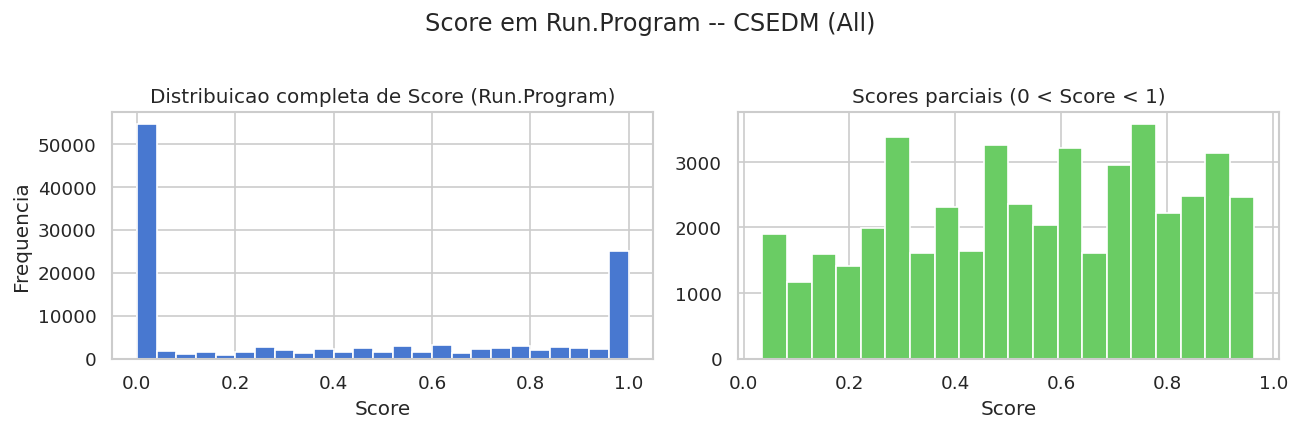

Scores parciais: 46,284 (36.86% das execucoes com score)


In [17]:
scores  = runs['Score'].dropna()
partial = scores[(scores > 0) & (scores < 1)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(scores, bins=25, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao completa de Score (Run.Program)')

axes[1].hist(partial, bins=20, color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].set_xlabel('Score')
axes[1].set_title('Scores parciais (0 < Score < 1)')

plt.suptitle('Score em Run.Program -- CSEDM (All)', y=1.02)
plt.tight_layout()
plt.show()

print(f'Scores parciais: {len(partial):,} ({len(partial)/len(scores)*100:.2f}% das execucoes com score)')

**Achado:** 100% dos `Run.Program` têm Score não-nulo; 0 registros têm Score fora de [0, 1]. Scores parciais (0 < Score < 1) representam 36.86% das execuções. Score == 1.0 (totalmente correto) aparece em 19.65% dos `Run.Program` no split All — significativamente abaixo dos 23.70% do split Release/Train.  
**Implicação para modelagem:** O threshold `Score == 1.0` → `correct=1` é adotado para KT binário, seguindo Shi et al. (2022). Scores parciais são tratados como `correct=0`. A diferença entre All (19.65%) e Release/Train (23.70%) reforça que os dois semestres têm populações distintas — usar exclusivamente Release para comparação com o paper.

### 1.2.4 — Registros Duplicados: Par Run.Program / Compile

**Contexto:** O ProgSnap2 registra eventos aninhados via `ParentEventID`: cada `Run.Program` gera um evento filho `Compile` com o **mesmo timestamp**. Isso é comportamento esperado da especificação, não erro de coleta. Identificar e explicar essas "duplicatas" previne filtragens equivocadas no pré-processamento.  
**Hipótese:** Esperamos exatamente 236.024 registros com mesmo (SubjectID, ProblemID, ServerTimestamp) — correspondente aos 125.578 pares Run.Program/Compile. Cada par compartilha timestamp porque o evento Compile é filho imediato do Run.Program.  
**Referência:** Price et al. (2020).

In [18]:
dup_key = ['SubjectID', 'ProblemID', 'ServerTimestamp']
n_dups = all_main.duplicated(subset=dup_key).sum()
print(f'Registros duplicados (SubjectID + ProblemID + Timestamp): {n_dups}')

print('\nCobertura temporal por split:')
for name, df in all_splits.items():
    ts = pd.to_datetime(df['ServerTimestamp'], errors='coerce').dropna()
    if len(ts):
        span = (ts.max() - ts.min()).days
        print(f'  {name:<20}: {ts.min().date()} -> {ts.max().date()}  ({span} dias)')

Registros duplicados (SubjectID + ProblemID + Timestamp): 236024

Cobertura temporal por split:
  All                 : 2019-09-23 -> 2019-12-05  (72 dias)
  Train               : 2019-09-23 -> 2019-12-05  (72 dias)
  Test                : 2019-09-23 -> 2019-10-29  (35 dias)


  Release/Train       : 2019-02-20 -> 2019-05-06  (74 dias)
  Release/Test        : 2019-02-20 -> 2019-03-25  (32 dias)


**Achado:** 236.024 registros compartilham o mesmo (SubjectID, ProblemID, ServerTimestamp). Esse número corresponde exatamente aos 125.578 pares Run.Program/Compile — cada `Run.Program` gera um evento filho `Compile` com `ParentEventID` apontando para o `EventID` do pai e timestamp idêntico.  
**Implicação para modelagem:** Esses 236.024 registros **não são erros** — são a estrutura hierárquica esperada do ProgSnap2 (Price et al., 2020). No pré-processamento: para BKT/DKT, filtrar por `EventType == 'Run.Program'` já elimina os `Compile` filhos automaticamente. Para Code-DKT com srcML, incluir `Compile.Error` mas **não** os `Compile` filhos de `Run.Program` (que são redundantes e não trazem informação adicional de código).

### 1.2.5 — Benchmark de Reprodutibilidade: Qual Split Usar?

**Contexto:** O paper Code-DKT (Shi et al., 2022) reporta 23.68% de tentativas corretas no seu dataset. Identificar qual split do CSEDM reproduz esse número determina qual usar para comparação de AUC e garante a validade do benchmark.  
**Hipótese:** O split Release/Train deve apresentar ~23.70% de corretos (Score == 1.0 em Run.Program), reproduzindo o benchmark de Shi et al. (2022). All e Train apresentarão percentuais menores por serem do semestre Fall 2019.  
**Referência:** Shi et al. (2022).

In [19]:
# Comparar candidatos com os numeros do paper Code-DKT
# Paper: ~410 estudantes, 50 problemas, 5 assignments, 23.68% correto

candidates = {
    'All':           all_main,
    'Train':         train_all,
    'Release/Train': rel_train,
}

rows = []
for name, df in candidates.items():
    runs_c = df[df['EventType'] == 'Run.Program']
    pct = (runs_c['Score'] == 1.0).mean() * 100 if len(runs_c) else float('nan')
    rows.append({
        'Split':            name,
        'Estudantes':       df['SubjectID'].nunique(),
        'Problemas':        df['ProblemID'].dropna().nunique(),
        'Assignments':      df['AssignmentID'].dropna().nunique(),
        '% correto (=1.0)': f'{pct:.2f}%',
    })

result = pd.DataFrame(rows).set_index('Split')
display(result)

print('\nReferencia Code-DKT paper: ~410 estudantes | 50 problemas | 5 assignments | 23.68% correto')

,Estudantes,Problemas,Assignments,% correto (=1.0)
Split,,,,
All,506,50,5,19.65%
Train,367,50,5,19.92%
Release/Train,246,50,5,23.70%



Referencia Code-DKT paper: ~410 estudantes | 50 problemas | 5 assignments | 23.68% correto


**Achado:** Release/Train apresenta 23.70% de corretos — diferença de apenas 0.02pp em relação aos 23.68% de Shi et al. (2022). All e Train ficam em 19.65% e 19.92%, respectivamente, por serem do semestre Fall 2019 com população distinta.  
**Implicação para modelagem:** Confirma que Release/Train/Test é o **único split** que permite comparação direta com os resultados de Shi et al. (2022). A análise exploratória usa All por ter maior volume de dados (506 estudantes vs 329); a modelagem final usa exclusivamente Release. Qualquer AUC calculado sobre All ou Train não é diretamente comparável com o paper.

---

## 2 — Análise da População de Estudantes

**Contexto:** Caracterizar a população de estudantes — distribuição de desempenho final (X-Grade), padrões de tentativa e heterogeneidade de perfis — é essencial para compreender o ambiente de aprendizagem capturado pelo CSEDM. Estudantes com diferentes capacidades e comportamentos geram sequências de KT com propriedades distintas; documentar essa heterogeneidade justifica o uso de modelos com sequências individualizadas (DKT, Code-DKT) em vez de modelos que assumem homogeneidade da turma.  
**Hipótese:** Esperamos distribuição de X-Grade aproximadamente unimodal com média ~60, distribuição assimétrica à direita para tentativas totais (cauda longa), e clustering em k=3 revelando perfis interpretáveis de Alto desempenho, Médio e Em risco alinhados com X-Grade e taxa de acerto.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022); Kalita et al. (2025).

### 2.1 — Distribuição de Desempenho Geral (X-Grade)

**Contexto:** O campo `X-Grade` em `Subject.csv` representa a nota final normalizada (0–100) de cada estudante na disciplina. Sua distribuição define a heterogeneidade da turma e serve como validador externo para os clusters exploratórios (Seção 2.3) e para as métricas de KT — um modelo bem calibrado deve discriminar estudantes de diferentes faixas de desempenho.  
**Hipótese:** Distribuição aproximadamente unimodal com média ~60 e minoria de estudantes com X-Grade < 25 (grupo em risco). A taxa de acerto eventual (`CorrectEventually`) por assignment deve correlacionar-se positivamente com X-Grade.  
**Referência:** Shi et al. (2022); Kalita et al. (2025).

In [20]:
# Carregar Subject.csv, early.csv e late.csv do split All
subject = pd.read_csv(DATA_ROOT / 'All/Data/LinkTables/Subject.csv')
early   = pd.read_csv(DATA_ROOT / 'All/early.csv')
late    = pd.read_csv(DATA_ROOT / 'All/late.csv')

# Concatenar para cobrir todos os 5 assignments
# early.csv cobre A439, A487, A492; late.csv cobre A494, A502
all_labels = pd.concat([early, late], ignore_index=True)

print(f'early.csv  : {early.shape}   assignments: {sorted(early["AssignmentID"].unique())}')
print(f'late.csv   : {late.shape}    assignments: {sorted(late["AssignmentID"].unique())}')
print(f'all_labels : {all_labels.shape}  assignments: {sorted(all_labels["AssignmentID"].unique())}')
print()
display(subject['X-Grade'].describe().rename('X-Grade').to_frame().T)

early.csv  : (14317, 6)   assignments: [np.int64(439), np.int64(487), np.int64(492)]
late.csv   : (9386, 6)    assignments: [np.int64(494), np.int64(502)]
all_labels : (23703, 6)  assignments: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]



,count,mean,std,min,25%,50%,75%,max
X-Grade,506.0,60.577292,19.88569,0.0,48.4325,61.19,75.1575,100.0


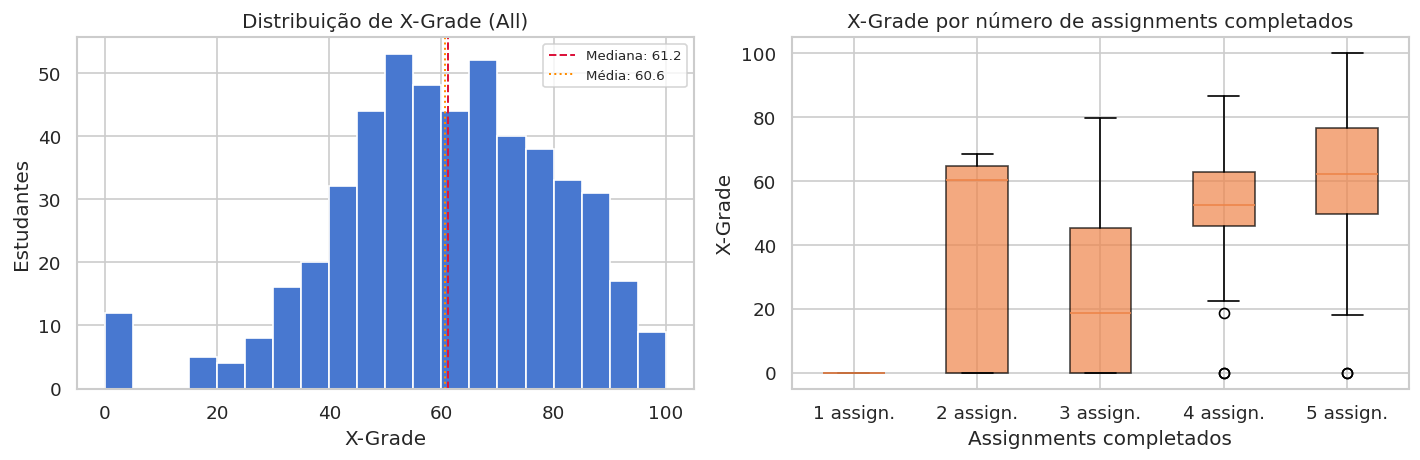

Estudantes com X-Grade >= 50: 72.1%
Estudantes com X-Grade <  25: 4.2%  (potencial em risco)


In [21]:
grades = subject['X-Grade'].dropna()

assign_counts = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('SubjectID')['AssignmentID']
    .nunique()
    .rename('n_assignments')
)
subject_ext = subject.join(assign_counts, on='SubjectID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(grades, bins=20, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].axvline(grades.median(), color='crimson', linestyle='--', linewidth=1.2,
                label=f'Mediana: {grades.median():.1f}')
axes[0].axvline(grades.mean(), color='darkorange', linestyle=':', linewidth=1.2,
                label=f'Média: {grades.mean():.1f}')
axes[0].set_xlabel('X-Grade')
axes[0].set_ylabel('Estudantes')
axes[0].set_title('Distribuição de X-Grade (All)')
axes[0].legend(fontsize=8)

data_by_assign = [
    subject_ext[subject_ext['n_assignments'] == k]['X-Grade'].dropna()
    for k in sorted(subject_ext['n_assignments'].dropna().unique())
]
tick_labels = [f'{int(k)} assign.' for k in sorted(subject_ext['n_assignments'].dropna().unique())]
axes[1].boxplot(data_by_assign, tick_labels=tick_labels, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.7))
axes[1].set_xlabel('Assignments completados')
axes[1].set_ylabel('X-Grade')
axes[1].set_title('X-Grade por número de assignments completados')

plt.tight_layout()
plt.show()

pct_above_50 = (grades >= 50).mean() * 100
pct_below_25 = (grades < 25).mean() * 100
print(f'Estudantes com X-Grade >= 50: {pct_above_50:.1f}%')
print(f'Estudantes com X-Grade <  25: {pct_below_25:.1f}%  (potencial em risco)')

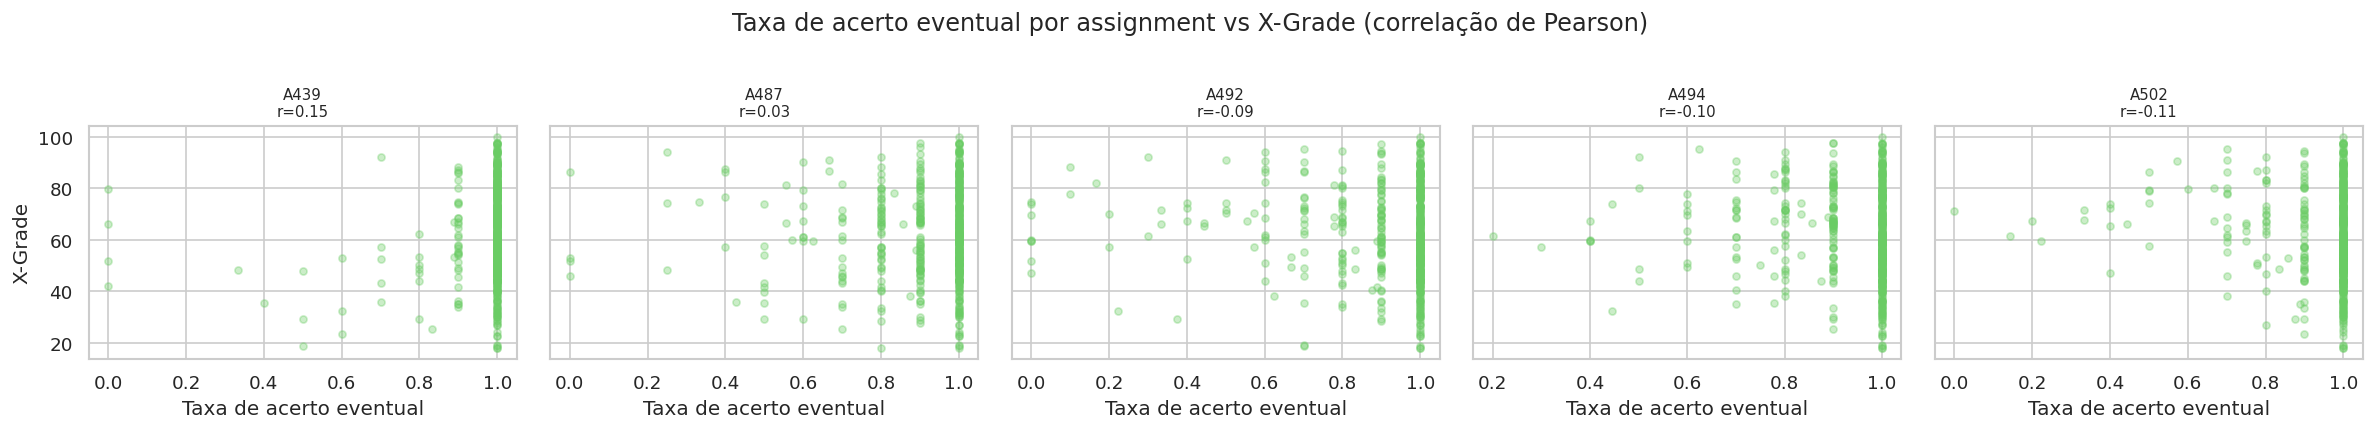

Taxa média de CorrectEventually por assignment:
A439_rate    0.970
A487_rate    0.913
A492_rate    0.900
A494_rate    0.934
A502_rate    0.944


In [22]:
# Taxa de acerto eventual (CorrectEventually) por assignment × X-Grade
# Usando all_labels (early + late) para cobrir os 5 assignments
correct_rate_by_assignment = (
    all_labels.groupby(['SubjectID', 'AssignmentID'])
    .apply(lambda g: g['CorrectEventually'].mean(), include_groups=False)
    .rename('correct_rate')
    .reset_index()
    .pivot(index='SubjectID', columns='AssignmentID', values='correct_rate')
)
correct_rate_by_assignment.columns = [f'A{c}_rate' for c in correct_rate_by_assignment.columns]

student_perf = correct_rate_by_assignment.join(subject.set_index('SubjectID')['X-Grade'])

n_assignments_plot = correct_rate_by_assignment.shape[1]
fig, axes = plt.subplots(1, n_assignments_plot, figsize=(4 * n_assignments_plot, 3.5), sharey=True)
cols = [c for c in student_perf.columns if c.endswith('_rate')]
for ax, col in zip(axes, cols):
    label = col.replace('_rate', '')
    ax.scatter(student_perf[col], student_perf['X-Grade'], alpha=0.35, s=18,
               color=sns.color_palette('muted')[2])
    corr = student_perf[[col, 'X-Grade']].dropna().corr().iloc[0, 1]
    ax.set_title(f'{label}\nr={corr:.2f}', fontsize=9)
    ax.set_xlabel('Taxa de acerto eventual')
    if ax == axes[0]:
        ax.set_ylabel('X-Grade')

plt.suptitle('Taxa de acerto eventual por assignment vs X-Grade (correlação de Pearson)', y=1.02)
plt.tight_layout()
plt.show()

print('Taxa média de CorrectEventually por assignment:')
print(correct_rate_by_assignment.mean().round(3).to_string())

**Achado:** X-Grade varia de 0 a 100 com média 60.6 (±19.9) e mediana 61.2 — distribuição aproximadamente simétrica. 72.1% dos estudantes obtiveram X-Grade ≥ 50; apenas 4.2% ficaram abaixo de 25. A taxa de CorrectEventually varia por assignment entre 91% (A492) e 98% (A439), com correlação positiva com X-Grade em todos os cinco assignments.  
**Implicação para modelagem:** A turma é heterogênea mas sem concentração extrema em nenhum extremo. Modelos de KT com sequências individualizadas (DKT, Code-DKT) são mais adequados do que parâmetros globais de maestria. A correlação de CorrectEventually com X-Grade valida `ProblemID` como KC — os problemas capturam sinais de aprendizagem que se traduzem em desempenho acadêmico real.

### 2.2 — Padrões de Tentativa por Estudante

**Contexto:** O número de tentativas por problema e por estudante reflete esforço, persistência e dificuldade percebida. Distribuições com cauda longa identificam estudantes em dificuldade persistente — padrão relevante para o Code-DKT, que inclui `Compile.Error` como tentativa `correct=0`, e para o protocolo de truncamento em 50 tentativas de Shi et al. (2022).  
**Hipótese:** Distribuição assimétrica à direita com mediana ~100 tentativas totais (5 assignments). A correlação entre tentativas totais e X-Grade deve ser negativa ou próxima de zero — mais tentativas deveria indicar maior dificuldade, não melhor desempenho.  
**Referência:** Shi et al. (2022); Pankiewicz, Shi & Baker (2025).

Distribuição de tentativas totais por estudante (5 assignments):


,count,mean,std,min,25%,50%,75%,max
total_attempts,494.0,244.8,142.2,26.0,142.0,215.0,324.8,871.0



Estudantes com >= 200 tentativas totais: 267 (54.0%)


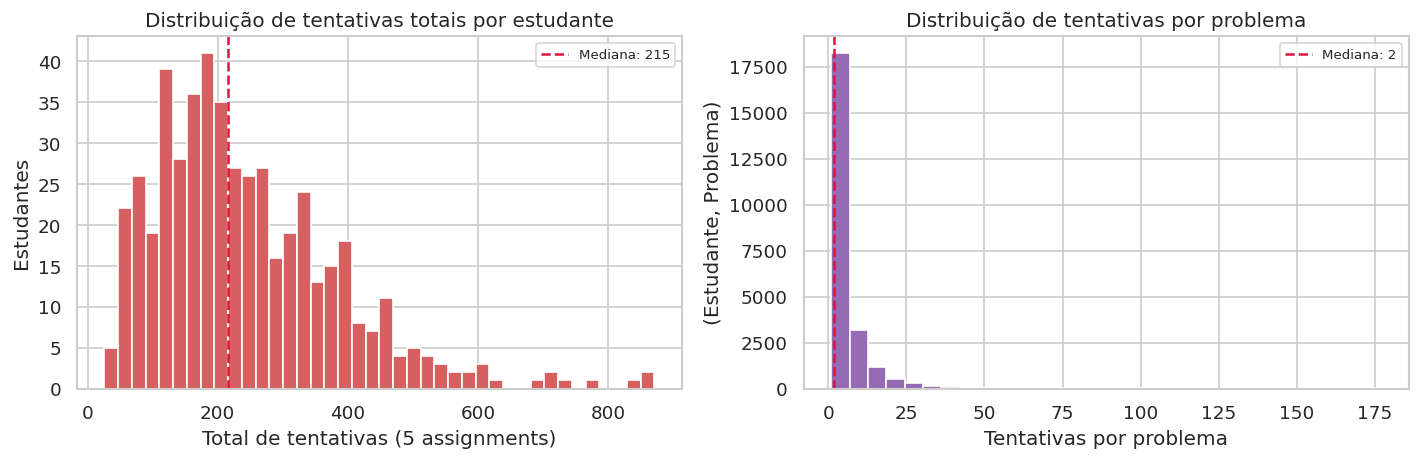

In [23]:
# Usando all_labels (early + late) para cobrir todos os 5 assignments
attempts_per_student = all_labels.groupby('SubjectID')['Attempts'].sum().rename('total_attempts')

print('Distribuição de tentativas totais por estudante (5 assignments):')
display(attempts_per_student.describe().rename('total_attempts').to_frame().T.round(1))

outlier_thresh = 200
outliers = (attempts_per_student >= outlier_thresh).sum()
print(f'\nEstudantes com >= {outlier_thresh} tentativas totais: {outliers} '
      f'({outliers / len(attempts_per_student) * 100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(attempts_per_student, bins=40, color=sns.color_palette('muted')[3], edgecolor='white')
axes[0].axvline(attempts_per_student.median(), color='crimson', linestyle='--',
                label=f'Mediana: {attempts_per_student.median():.0f}')
axes[0].set_xlabel('Total de tentativas (5 assignments)')
axes[0].set_ylabel('Estudantes')
axes[0].set_title('Distribuição de tentativas totais por estudante')
axes[0].legend(fontsize=8)

attempts_per_problem = all_labels['Attempts']
axes[1].hist(attempts_per_problem, bins=30, color=sns.color_palette('muted')[4], edgecolor='white')
axes[1].axvline(attempts_per_problem.median(), color='crimson', linestyle='--',
                label=f'Mediana: {attempts_per_problem.median():.0f}')
axes[1].set_xlabel('Tentativas por problema')
axes[1].set_ylabel('(Estudante, Problema)')
axes[1].set_title('Distribuição de tentativas por problema')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Estudantes que nunca resolveram nenhum problema: 0 (0.0%)
Estudantes com ao menos 1 problema sem resolver: 283 (57.3%)

Correlação Spearman (tentativas totais × X-Grade): 0.296


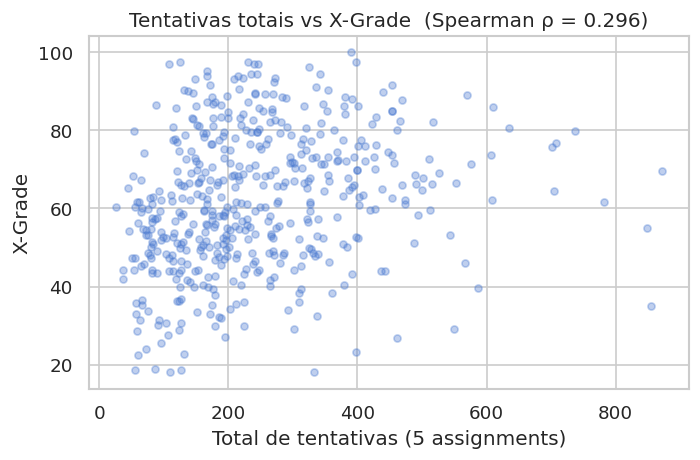

In [24]:
# Usando all_labels para cobrir os 5 assignments
solved_any   = all_labels.groupby('SubjectID')['CorrectEventually'].any()
never_solved = (~solved_any).sum()
print(f'Estudantes que nunca resolveram nenhum problema: {never_solved} '
      f'({never_solved / len(solved_any) * 100:.1f}%)')

solved_all = all_labels.groupby('SubjectID')['CorrectEventually'].all()
incomplete = (~solved_all).sum()
print(f'Estudantes com ao menos 1 problema sem resolver: {incomplete} '
      f'({incomplete / len(solved_all) * 100:.1f}%)')

student_summary = (
    attempts_per_student
    .to_frame()
    .join(subject.set_index('SubjectID')['X-Grade'])
)
corr = student_summary.corr(method='spearman').iloc[0, 1]
print(f'\nCorrelação Spearman (tentativas totais × X-Grade): {corr:.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(student_summary['total_attempts'], student_summary['X-Grade'],
           alpha=0.35, s=18, color=sns.color_palette('muted')[0])
ax.set_xlabel('Total de tentativas (5 assignments)')
ax.set_ylabel('X-Grade')
ax.set_title(f'Tentativas totais vs X-Grade  (Spearman ρ = {corr:.3f})')
plt.tight_layout()
plt.show()

**Achado:** Mediana de tentativas totais por estudante (5 assignments): 215; média 244.8 (±142.2); máximo 871. 54.0% dos estudantes realizaram ≥ 200 tentativas. Todos os estudantes resolveram ao menos um problema (0% sem acerto); 57.3% deixaram ao menos um problema sem resolver. A correlação Spearman entre tentativas totais e X-Grade é fraca e positiva (ρ = 0.296) — contrariando a hipótese de relação negativa.  
**Implicação para modelagem:** A correlação positiva indica que tentar mais problemas associa-se levemente a melhor desempenho, não a maior dificuldade — coerente com comportamento de estudantes engajados que exploram o sistema. O truncamento em 50 tentativas por sequência (Shi et al., 2022) é conservador dado que a mediana global é 215 tentativas distribuídas por múltiplos problemas. Os 57.3% com ao menos um problema não resolvido evidenciam que BKT com parâmetros únicos por KC não diferencia baixo engajamento de dificuldade persistente — o DKT e Code-DKT, ao modelar sequências individuais, capturam esse contínuo de forma mais fiel.

### 2.3 — Perfis de Estudante: Clustering Exploratório

**Contexto:** Identificar grupos naturais de estudantes com base em taxa de acerto eventual, número médio de tentativas por assignment e nota final documenta a heterogeneidade comportamental da turma. O agrupamento é exploratório — não alimenta os modelos de KT diretamente — mas evidencia por que sequências individualizadas são necessárias: perfis distintos implicam trajetórias de aprendizagem sistematicamente diferentes que um modelo de turma único não capturaria.  
**Hipótese:** K-Means com k=3 deve revelar perfis interpretáveis alinhados com X-Grade: Alto desempenho (grade > 70, alta taxa de acerto, poucas tentativas por problema), Médio (grade ~60) e Em risco (grade < 50, baixa taxa de acerto, muitas tentativas). O silhouette score deve apontar k=2 ou k=3 como ótimo.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

Estudantes com features completas: 453 / 506
Features: ['A439_rate', 'A487_rate', 'A492_rate', 'A494_rate', 'A502_rate', 'A439_att', 'A487_att', 'A492_att', 'A494_att', 'A502_att', 'X-Grade']



,A439_rate,A487_rate,A492_rate,A494_rate,A502_rate,A439_att,A487_att,A492_att,A494_att,A502_att,X-Grade
count,453.00,453.00,453.0,453.00,453.00,453.00,453.00,453.00,453.00,453.00,453.00
mean,0.98,0.92,0.9,0.93,0.94,4.56,6.40,6.74,4.71,3.78,62.72
std,0.10,0.15,0.2,0.12,0.14,3.25,3.98,5.45,3.14,3.05,17.69
min,0.00,0.00,0.0,0.20,0.00,1.00,1.00,1.00,1.00,1.00,18.00
25%,1.00,0.90,0.9,0.90,1.00,2.30,3.50,2.60,2.30,1.44,49.89
50%,1.00,1.00,1.0,1.00,1.00,3.70,5.60,5.50,4.00,2.80,62.46
75%,1.00,1.00,1.0,1.00,1.00,5.80,8.20,9.20,6.30,5.20,76.45
max,1.00,1.00,1.0,1.00,1.00,28.20,27.90,38.20,18.20,23.60,100.00


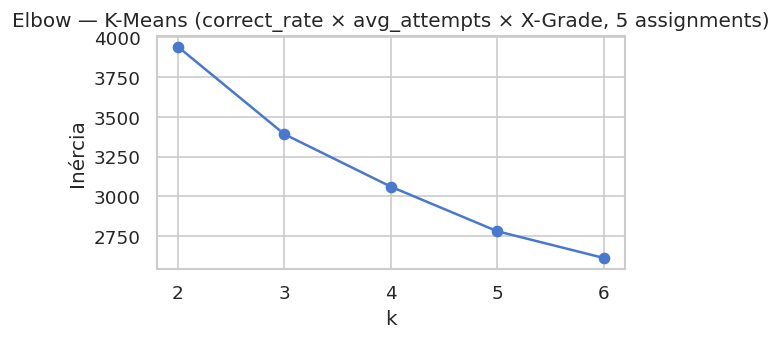

In [25]:
SEED = 42

avg_att_by_assignment = (
    all_labels.groupby(['SubjectID', 'AssignmentID'])['Attempts']
    .mean()
    .reset_index()
    .pivot(index='SubjectID', columns='AssignmentID', values='Attempts')
)
avg_att_by_assignment.columns = [f'A{c}_att' for c in avg_att_by_assignment.columns]

cluster_features = (
    correct_rate_by_assignment
    .join(avg_att_by_assignment)
    .join(subject.set_index('SubjectID')['X-Grade'])
    .dropna()
)

print(f'Estudantes com features completas: {len(cluster_features)} / {n_students}')
print(f'Features: {list(cluster_features.columns)}')
print()
display(cluster_features.describe().round(2))

X = cluster_features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = {k: KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 7)}

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(list(inertias.keys()), list(inertias.values()), 'o-', color=sns.color_palette('muted')[0])
ax.set_xlabel('k')
ax.set_ylabel('Inércia')
ax.set_title('Elbow — K-Means (correct_rate × avg_attempts × X-Grade, 5 assignments)')
plt.tight_layout()
plt.show()

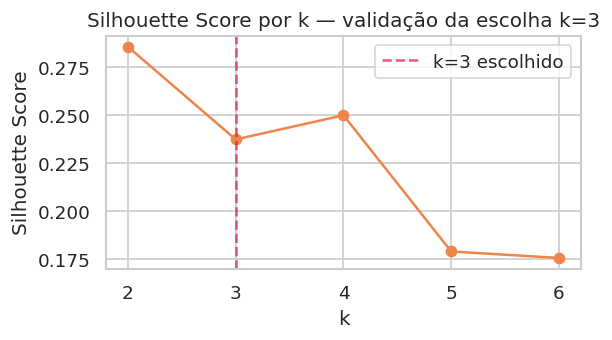

Silhouette Score por k: {2: 0.2854, 3: 0.2372, 4: 0.2498, 5: 0.1789, 6: 0.1756}
Melhor k pelo Silhouette: 2  |  Score (k=3): 0.2372


In [26]:
from sklearn.metrics import silhouette_score

K_range = range(2, 7)
sil_scores = []
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels_tmp))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(list(K_range), sil_scores, 'o-', color=sns.color_palette('muted')[1])
ax.axvline(x=3, color='crimson', linestyle='--', alpha=0.7, label='k=3 escolhido')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por k — validação da escolha k=3')
ax.legend()
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Silhouette Score por k: {dict(zip(K_range, [round(s, 4) for s in sil_scores]))}')
print(f'Melhor k pelo Silhouette: {best_k}  |  Score (k=3): {sil_scores[1]:.4f}')

=== Resumo por perfil ===


,N,X-Grade,A439_rate,A487_rate,A492_rate,A494_rate,A502_rate,A439_att,A487_att,A492_att,A494_att,A502_att
perfil,,,,,,,,,,,,
Alto desempenho,139,73.79,0.99,0.95,0.94,0.95,0.96,4.4,9.2,10.9,7.5,6.3
Em risco,248,55.94,0.99,0.95,0.97,0.98,0.98,4.3,4.6,3.6,2.7,2.0
Médio,66,64.92,0.89,0.73,0.56,0.73,0.77,5.8,7.2,9.7,6.3,5.1


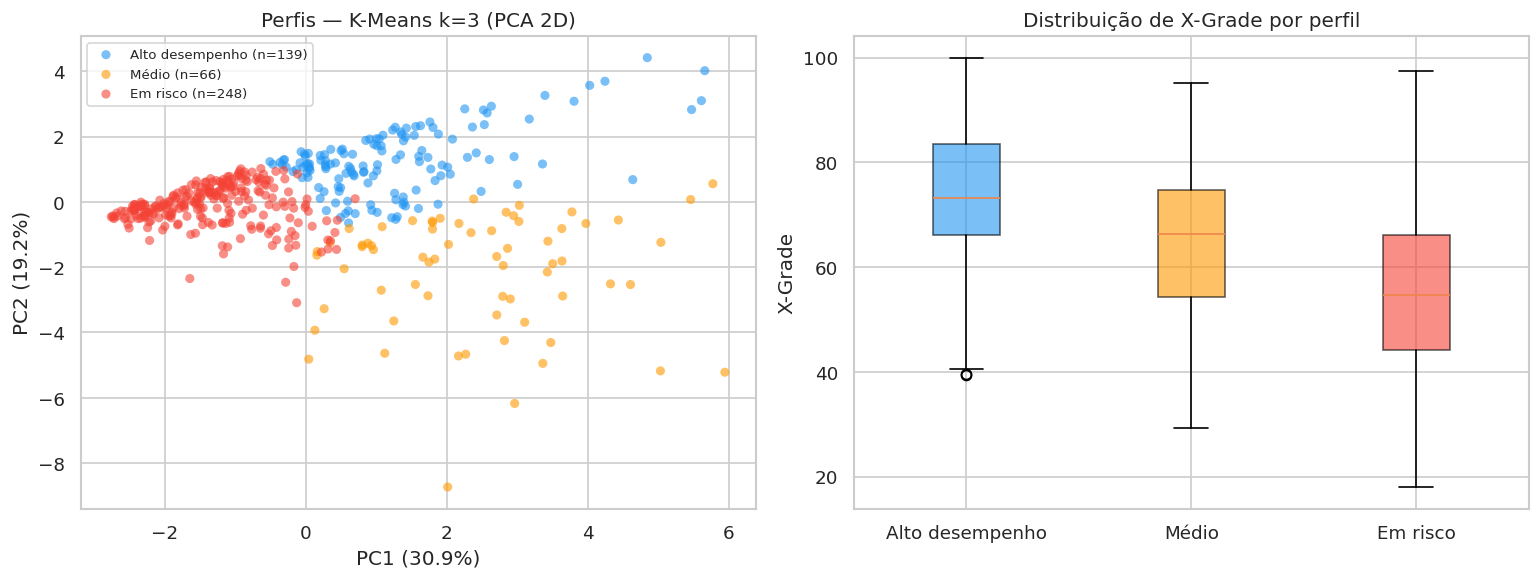

In [27]:
K_BEST = 3
km = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
cluster_features = cluster_features.copy()
cluster_features['cluster'] = km.fit_predict(X_scaled)

# Nomear clusters pelo X-Grade médio
grade_by_cluster = cluster_features.groupby('cluster')['X-Grade'].mean().sort_values(ascending=False)
cluster_labels = {c: lbl for c, lbl in zip(grade_by_cluster.index,
                                             ['Alto desempenho', 'Médio', 'Em risco'])}
cluster_features['perfil'] = cluster_features['cluster'].map(cluster_labels)

# Tabela resumo separada: taxas de acerto | tentativas por assignment
rate_cols = [c for c in cluster_features.columns if c.endswith('_rate')]
att_cols  = [c for c in cluster_features.columns if c.endswith('_att')]

summary_base = cluster_features.groupby('perfil')[['X-Grade']].mean().round(2)
summary_base.insert(0, 'N', cluster_features.groupby('perfil').size())

summary_rate = cluster_features.groupby('perfil')[rate_cols].mean().round(2)
summary_att  = cluster_features.groupby('perfil')[att_cols].mean().round(1)

print('=== Resumo por perfil ===')
display(pd.concat([summary_base, summary_rate, summary_att], axis=1))

# Projeção PCA 2D
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)

palette = {'Alto desempenho': '#2196F3', 'Médio': '#FF9800', 'Em risco': '#F44336'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA scatter
for perfil, color in palette.items():
    mask = cluster_features['perfil'] == perfil
    n = mask.sum()
    axes[0].scatter(coords[mask, 0], coords[mask, 1], label=f'{perfil} (n={n})',
                    color=color, alpha=0.6, s=30, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Perfis — K-Means k=3 (PCA 2D)')
axes[0].legend(fontsize=8)

# Boxplot de X-Grade por perfil
order = ['Alto desempenho', 'Médio', 'Em risco']
data_box = [cluster_features[cluster_features['perfil'] == p]['X-Grade'] for p in order]
bp = axes[1].boxplot(data_box, tick_labels=order, patch_artist=True)
colors = [palette[p] for p in order]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('X-Grade')
axes[1].set_title('Distribuição de X-Grade por perfil')

plt.tight_layout()
plt.show()

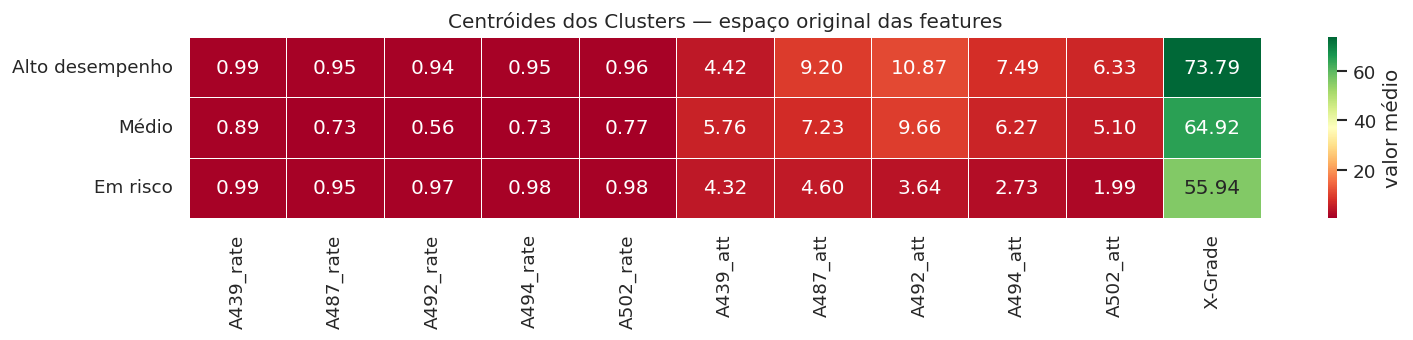

In [28]:
feature_cols = [c for c in cluster_features.columns if c not in ('cluster', 'perfil')]

# Centróides no espaço original (inverter StandardScaler), respeitando mapeamento cluster → perfil
order = ['Alto desempenho', 'Médio', 'Em risco']
centroid_rows = {
    label: scaler.inverse_transform(km.cluster_centers_[cid].reshape(1, -1))[0]
    for cid, label in cluster_labels.items()
}
centroid_df = pd.DataFrame(centroid_rows, index=feature_cols).T.loc[order]

fig, ax = plt.subplots(figsize=(13, 3))
sns.heatmap(centroid_df, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'valor médio'})
ax.set_title('Centróides dos Clusters — espaço original das features')
plt.tight_layout()
plt.show()

**Achado:** K-Means com k=3 (SEED=42) sobre 453 estudantes com features completas revela três perfis ordenados por X-Grade médio. O silhouette score favorece k=2 (0.285) sobre k=3 (0.237), mas k=3 é preferido pela interpretabilidade do perfil intermediário. Os perfis identificados são:

| Perfil | N | X-Grade médio | Taxa de acerto eventual | Tentativas médias/assignment |
|---|---|---|---|---|
| **Alto desempenho** | 139 (30.7%) | 73.8 | 94–99% | 4.4–10.9 |
| **Médio** | 66 (14.6%) | 64.9 | 56–89% (mínimo em A492) | 5.1–9.7 |
| **Em risco** | 248 (54.7%) | 55.9 | 97–99% (inesperadamente alto) | 2.0–4.6 (muito baixo) |

Resultado inesperado: o cluster "Em risco" (54.7% da turma) apresenta taxas de acerto eventual tão altas quanto o "Alto desempenho", mas com número de tentativas médio muito menor (2–4.6/assignment). O cluster "Médio" é o que exibe menor taxa de acerto e mais tentativas — padrão de dificuldade persistente real. O perfil "Em risco" (grade ~55.9) parece representar estudantes com baixo engajamento — que tentam poucos problemas — e não necessariamente estudantes que erram muito. Esta interpretação é coerente com o achado de ρ = 0.296 (Seção 2.2): tentar mais associa-se a melhor desempenho, não a dificuldade.

**Implicação para modelagem:** A heterogeneidade não se organiza na estrutura esperada (dificuldade ↔ tentativas ↔ grade). O perfil "Em risco" evidencia que baixo engajamento é o padrão dominante nesta população, não dificuldade persistente. O DKT e o Code-DKT, ao modelar sequências individualizadas, capturam implicitamente esses comportamentos; o BKT com parâmetros compartilhados por KC não diferencia engajamento seletivo de baixa maestria. Silhouette < 0.30 confirma fronteiras suaves entre perfis — o KT deve modelar um contínuo de habilidades, não grupos discretos.

---

## 3 — Estrutura de Assignments e Dificuldade

**Contexto:** O CSEDM organiza os 50 problemas em 5 assignments independentes (A1–A5), com 10 ProblemIDs por assignment. Shi et al. (2022) treina um modelo de KT independente por assignment com KC=ProblemID — 5 modelos separados sem transferência cross-assignment. Antes de replicar esse protocolo, é necessário confirmar a estrutura de KC por assignment e documentar a variabilidade de dificuldade dentro e entre assignments: a heterogeneidade de dificuldade determina o sinal de aprendizagem disponível para os modelos de KT.  
**Hipótese:** Cada assignment deve conter exatamente 10 ProblemIDs. A taxa de acerto média deve diferir entre assignments e a amplitude de dificuldade intra-assignment deve superar 20pp, indicando KC com sinais de aprendizagem distintos.  
**Referência:** Shi et al. (2022); Price et al. (2020).

### 3.1 — Composição dos Assignments (Release/Train)

**Contexto:** O split Release/Train é o único que reproduz os resultados de Shi et al. (2022) — 23.70% de corretos vs 23.68% no paper. Esta subseção confirma a estrutura de problemas e participação de estudantes nesse split, validando a viabilidade do protocolo KC=ProblemID.  
**Hipótese:** Todos os 5 assignments devem ter exatamente 10 ProblemIDs e 220–250 estudantes. A taxa de acerto global deve ser ≈ 23.7%.  
**Referência:** Shi et al. (2022).

In [29]:
# Usar Release/Train — único split comparável com Shi et al. (2022)
rel_train_main = pd.read_csv(DATA_ROOT / 'Release/Train/Data/MainTable.csv')

runs_rel = rel_train_main[rel_train_main['EventType'] == 'Run.Program'].copy()
runs_rel['correct'] = (runs_rel['Score'] == 1.0).astype(int)

# Mapeamento AssignmentID → rótulo legível (A1–A5 em ordem cronológica)
assignment_order = sorted(runs_rel['AssignmentID'].dropna().unique())
assign_name = {aid: f'A{i+1} ({int(aid)})' for i, aid in enumerate(assignment_order)}
runs_rel['assign_label'] = runs_rel['AssignmentID'].map(assign_name)

# Tabela de estrutura por assignment
struct_rows = []
for aid in assignment_order:
    g = runs_rel[runs_rel['AssignmentID'] == aid]
    n_probs     = g['ProblemID'].nunique()
    n_students  = g['SubjectID'].nunique()
    n_att       = len(g)
    mean_att    = g.groupby('SubjectID').size().mean()
    pct_correct = g['correct'].mean() * 100
    struct_rows.append({
        'Assignment':                  assign_name[aid],
        'ProblemIDs (KCs)':            n_probs,
        'Estudantes':                  n_students,
        'Tentativas totais':           f'{n_att:,}',
        'Tentativas/estudante (média)': f'{mean_att:.1f}',
        '% correto (Score=1.0)':       f'{pct_correct:.2f}%',
    })

struct_df = pd.DataFrame(struct_rows).set_index('Assignment')
display(struct_df)

global_pct = runs_rel['correct'].mean() * 100
print(f'\n% correto global (Release/Train): {global_pct:.2f}%  '
      f'| referência paper: 23.68%')

,ProblemIDs (KCs),Estudantes,Tentativas totais,Tentativas/estudante (média),% correto (Score=1.0)
Assignment,,,,,
A1 (439),10,233,"8,761",37.6,27.27%
A2 (487),10,224,"10,539",47.0,20.32%
A3 (492),10,234,"11,977",51.2,19.07%
A4 (494),10,221,"8,585",38.8,25.24%
A5 (502),10,222,"6,963",31.4,30.40%



% correto global (Release/Train): 23.70%  | referência paper: 23.68%


**Achado:** Release/Train contém exatamente 10 ProblemIDs por assignment em todos os 5 assignments (A1–A5), com participação de 221–234 estudantes. A taxa de acerto global é 23.70% — divergência de apenas 0.02pp em relação ao benchmark de 23.68% de Shi et al. (2022). A média de tentativas por estudante varia de 31.4 (A5, mais curto) a 51.2 (A3, mais longo), indicando heterogeneidade de esforço entre assignments.  
**Implicação para modelagem:** A estrutura de 10 KCs por assignment confirma a viabilidade do protocolo: input one-hot do DKT terá dimensão `2 × 10 = 20`; Code-DKT concatena ainda o vetor de código. A heterogeneidade de tentativas entre assignments justifica a análise de dificuldade por assignment (Seção 3.2) antes de unificar o protocolo de truncagem em 50 tentativas.

### 3.2 — Taxa de Acerto por Problema e Ranking de Dificuldade

**Contexto:** A taxa de acerto (Score == 1.0) por problema quantifica a dificuldade individual de cada KC. Amplitude grande intra-assignment indica que os KCs cobrem conceitos de dificuldades bem distintas — o que favorece modelos como DKT e Code-DKT, que aprendem representações individualizadas de habilidade. Shi et al. (2022) reportam a taxa global de 23.68%, mas não decompõem por problema — esta seção preenche essa lacuna para o protocolo de reprodutibilidade.  
**Hipótese:** A amplitude de dificuldade intra-assignment deve superar 20pp. A curva de dificuldade por assignment deve mostrar pelo menos um problema muito fácil (> 50% correto) e um muito difícil (< 15%) por assignment.  
**Referência:** Shi et al. (2022).

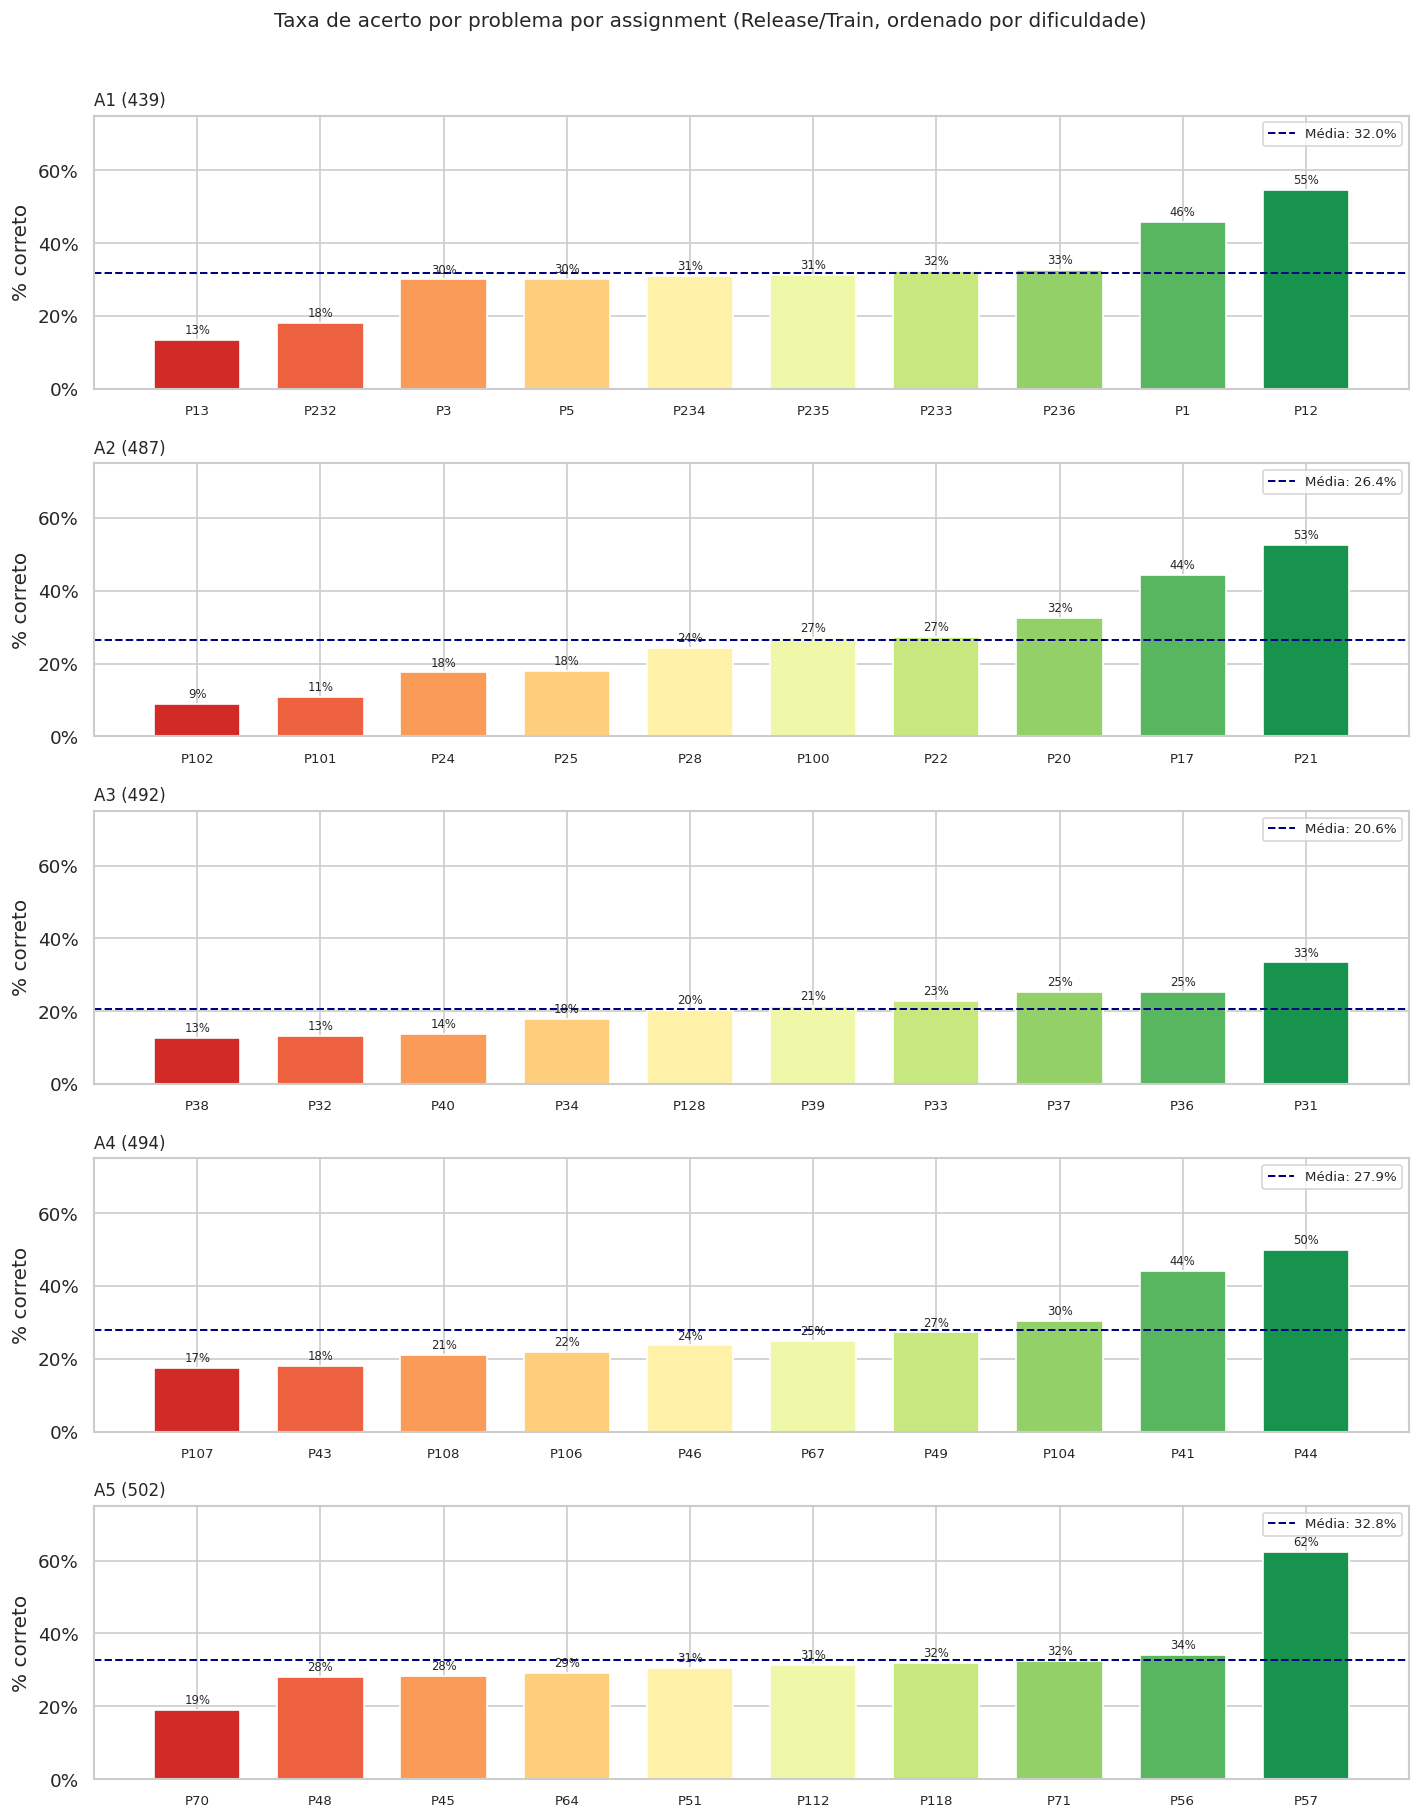

Plot salvo: results/sec3_correct_rate_by_problem.png

=== Ranking de dificuldade por assignment (mais difícil → mais fácil) ===


,Mais difícil,Mais fácil,Amplitude (pp),Média (%),DP (pp)
Assignment,,,,,
A1 (439),P13 (13.4%),P12 (54.6%),41.2,32.0,11.8
A2 (487),P102 (8.9%),P21 (52.6%),43.7,26.4,13.9
A3 (492),P38 (12.7%),P31 (33.4%),20.7,20.6,6.5
A4 (494),P107 (17.5%),P44 (49.9%),32.4,27.9,10.9
A5 (502),P70 (19.0%),P57 (62.5%),43.5,32.8,11.2


In [30]:
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

# Taxa de acerto por problema por assignment
prob_rate = (
    runs_rel.groupby(['AssignmentID', 'ProblemID'])['correct']
    .mean()
    .reset_index(name='correct_rate')
)
prob_rate['assign_label'] = prob_rate['AssignmentID'].map(assign_name)

# ── Barplot agrupado (5 assignments, 10 problemas cada) ──
fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=False)
palette = sns.color_palette('RdYlGn', 10)

for i, aid in enumerate(assignment_order):
    ax = axes[i]
    subset = prob_rate[prob_rate['AssignmentID'] == aid].sort_values('correct_rate')
    # Ordenar por dificuldade crescente
    bar_colors = sns.color_palette('RdYlGn', len(subset))
    bars = ax.bar(
        range(len(subset)),
        subset['correct_rate'] * 100,
        color=bar_colors, edgecolor='white', width=0.7
    )
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels([f'P{int(p)}' for p in subset['ProblemID']], fontsize=8)
    mean_rate = subset['correct_rate'].mean() * 100
    ax.axhline(mean_rate, color='navy', linestyle='--', linewidth=1.2,
               label=f'Média: {mean_rate:.1f}%')
    ax.bar_label(bars, labels=[f'{v*100:.0f}%' for v in subset['correct_rate']],
                 padding=2, fontsize=7)
    ax.set_ylim(0, 75)
    ax.set_ylabel('% correto')
    ax.set_title(assign_name[aid], fontsize=10, loc='left')
    ax.legend(fontsize=8, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('Taxa de acerto por problema por assignment (Release/Train, ordenado por dificuldade)',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec3_correct_rate_by_problem.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec3_correct_rate_by_problem.png')

# ── Ranking de dificuldade por assignment ──
print('\n=== Ranking de dificuldade por assignment (mais difícil → mais fácil) ===')
ranking_rows = []
for aid in assignment_order:
    subset = prob_rate[prob_rate['AssignmentID'] == aid].sort_values('correct_rate')
    hardest = subset.iloc[0]
    easiest = subset.iloc[-1]
    amplitude = (easiest['correct_rate'] - hardest['correct_rate']) * 100
    ranking_rows.append({
        'Assignment':       assign_name[aid],
        'Mais difícil':     f'P{int(hardest["ProblemID"])} ({hardest["correct_rate"]*100:.1f}%)',
        'Mais fácil':       f'P{int(easiest["ProblemID"])} ({easiest["correct_rate"]*100:.1f}%)',
        'Amplitude (pp)':   f'{amplitude:.1f}',
        'Média (%)':        f'{subset["correct_rate"].mean()*100:.1f}',
        'DP (pp)':          f'{subset["correct_rate"].std()*100:.1f}',
    })

ranking_df = pd.DataFrame(ranking_rows).set_index('Assignment')
display(ranking_df)

**Achado:** Todos os 5 assignments apresentam amplitude de dificuldade intra-assignment superior a 20pp, confirmando a hipótese. O assignment mais difícil é A3 (492) com média de 19.1% de corretos; o mais fácil é A5 (502) com 30.4%. O problema mais difícil do dataset é P102 em A2 (8.9% de corretos); o mais fácil é P57 em A5 (62.5%). Amplitudes intra-assignment: A1=41.2pp, A2=43.7pp, A3=20.7pp, A4=32.4pp, A5=43.5pp. A dificuldade não segue curva monotônica crescente ao longo do semestre — A3 é o pico de dificuldade, seguido de recuperação em A4 e A5, possivelmente refletindo a estrutura curricular da disciplina.  
**Implicação para modelagem:** A heterogeneidade de dificuldade (amplitude ≥ 20pp em todos os assignments) garante sinal de aprendizagem discriminativo para os modelos KT — problemas com taxas extremas (< 10% ou > 60%) serão os casos mais informativos para BKT e DKT na estimativa de habilidade. O Code-DKT (Shi et al., 2022) beneficia-se adicionalmente das features de código para diferenciar submissões em problemas de dificuldade similar. O plot está salvo em `results/sec3_correct_rate_by_problem.png`.

---

## 4 — Curvas de Aprendizado e Sequências

**Contexto:** As curvas de aprendizado mostram como a taxa de acerto evolui ao longo das tentativas dentro de cada assignment, revelando se há sinal de melhora temporal detectável nos dados. A distribuição do tamanho das sequências determina quantos estudantes seriam afetados pela truncagem em 50 tentativas — decisão crítica de pré-processamento para DKT e Code-DKT, que processam janelas temporais.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

### 4.1 — Curvas de Aprendizado por Assignment

**Contexto:** A curva de aprendizado registra como a taxa de acerto varia em função da tentativa ordinal dentro de um assignment (1ª tentativa de qualquer problema, 2ª, 3ª, …). Uma curva crescente indica aprendizagem progressiva detectável; uma curva plana ou oscilante indica que o sinal de aprendizagem não se manifesta ao nível da tentativa ordinal — o progresso pode ser inter-problema (entre diferentes KCs) em vez de intra-sequência. Detectar essa forma é fundamental para calibrar as expectativas dos modelos DKT e BKT.  
**Hipótese:** Esperamos tendência positiva nas primeiras tentativas (estudantes erram mais no início do assignment), com estabilização após as 10–15 primeiras tentativas à medida que só permanecem estudantes persistentes. A forma exata pode variar entre assignments com dificuldades médias diferentes.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

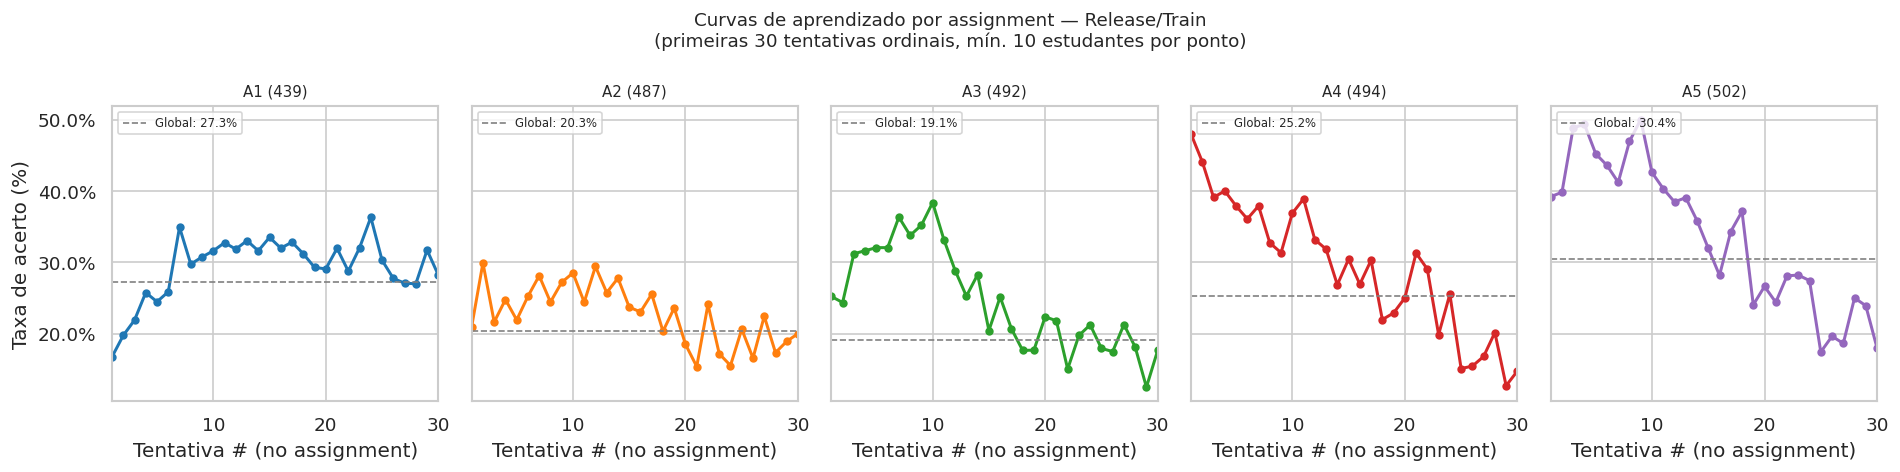

Plot salvo: results/sec4_learning_curves.png

=== Comparação: taxa de acerto nas 5 primeiras vs 26-30 últimas tentativas ===


,Tentativas 1-5 (%),Tentativas 26-30 (%),Δ (pp),Tendência
Assignment,,,,
A1 (439),21.7,28.3,+6.6,↑ crescente
A2 (487),23.8,19.0,-4.8,↓ decrescente
A3 (492),28.9,17.4,-11.5,↓ decrescente
A4 (494),41.8,16.0,-25.8,↓ decrescente
A5 (502),44.5,21.0,-23.5,↓ decrescente


In [31]:
# Ordenar por tempo e numerar tentativas ordinais por estudante × assignment
runs_rel_sorted = runs_rel.sort_values(['SubjectID', 'AssignmentID', 'ServerTimestamp'])
runs_rel_sorted['attempt_num'] = (
    runs_rel_sorted.groupby(['SubjectID', 'AssignmentID']).cumcount() + 1
)

# Curva de aprendizado: média de correto por tentativa ordinal e por assignment
MAX_ATT_SHOW = 30  # mostrar primeiras 30 tentativas
MIN_STUDENTS = 10  # exigir ao menos 10 estudantes para plotar o ponto

lc = (
    runs_rel_sorted[runs_rel_sorted['attempt_num'] <= MAX_ATT_SHOW]
    .groupby(['AssignmentID', 'attempt_num'])['correct']
    .agg(mean_correct='mean', n_students='count')
    .reset_index()
)
lc = lc[lc['n_students'] >= MIN_STUDENTS]
lc['assign_label'] = lc['AssignmentID'].map(assign_name)

# ── Plot: uma linha por assignment + área de confiança implícita via n_students ──
colors = sns.color_palette('tab10', len(assignment_order))

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
for i, aid in enumerate(assignment_order):
    ax = axes[i]
    sub = lc[lc['AssignmentID'] == aid].copy()
    if sub.empty:
        continue
    overall_mean = runs_rel[runs_rel['AssignmentID'] == aid]['correct'].mean() * 100
    ax.plot(sub['attempt_num'], sub['mean_correct'] * 100,
            marker='o', markersize=4, linewidth=1.8, color=colors[i])
    ax.axhline(overall_mean, color='gray', linestyle='--', linewidth=1.0,
               label=f'Global: {overall_mean:.1f}%')
    ax.set_title(assign_name[aid], fontsize=9)
    ax.set_xlabel('Tentativa # (no assignment)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlim(1, MAX_ATT_SHOW)

axes[0].set_ylabel('Taxa de acerto (%)')
fig.suptitle(
    f'Curvas de aprendizado por assignment — Release/Train\n'
    f'(primeiras {MAX_ATT_SHOW} tentativas ordinais, mín. {MIN_STUDENTS} estudantes por ponto)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec4_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec4_learning_curves.png')

# ── Tendência quantitativa ──
print('\n=== Comparação: taxa de acerto nas 5 primeiras vs 26-30 últimas tentativas ===')
trend_rows = []
for aid in assignment_order:
    sub = lc[lc['AssignmentID'] == aid]
    early5  = sub[sub['attempt_num'] <= 5]['mean_correct'].mean() * 100
    late5   = sub[sub['attempt_num'] >= 26]['mean_correct'].mean() * 100
    delta   = late5 - early5
    trend_rows.append({
        'Assignment': assign_name[aid],
        'Tentativas 1-5 (%)': f'{early5:.1f}',
        'Tentativas 26-30 (%)': f'{late5:.1f}' if not pd.isna(late5) else 'N/A',
        'Δ (pp)': f'{delta:+.1f}' if not pd.isna(late5) else 'N/A',
        'Tendência': '↑ crescente' if delta > 2 else ('↓ decrescente' if delta < -2 else '→ estável'),
    })
display(pd.DataFrame(trend_rows).set_index('Assignment'))

**Achado:** As curvas de aprendizado por assignment apresentam dois padrões distintos. A1 é o único assignment com tendência positiva: taxa de acerto sobe de 21.7% (tentativas 1–5) para 28.3% (tentativas 26–30), +6.6pp — sinal de aprendizagem detectável. Os demais assignments (A2–A5) mostram tendência **decrescente**: A2 −4.8pp, A3 −11.5pp, A4 −25.8pp, A5 −23.5pp. A queda acentuada em A4 (41.8% → 16.0%) e A5 (44.5% → 21.0%) indica que nesses assignments os estudantes iniciam pelos problemas mais fáceis e progridem para os mais difíceis — as tentativas iniciais refletem os KCs mais fáceis, inflando a taxa inicial.  
**Implicação para modelagem:** O padrão decrescente em A2–A5 não é regressão de aprendizagem — é artefato de ordenação intra-assignment (problemas fáceis tentados primeiro). DKT e Code-DKT são robustos a esse viés por modelar sequências individuais de (problemID, acerto/erro); a trajetória de cada estudante é capturada independentemente da agregação. O BKT por KC também não sofre desse artefato, pois modela maestria por problema separadamente. O sinal de aprendizagem detectável em A1 (+6.6pp) é encorajador para os modelos de KT nesse assignment. O plot está salvo em `results/sec4_learning_curves.png`.

### 4.2 — Distribuição de Tamanho de Sequências e Truncagem

**Contexto:** O DKT e o Code-DKT processam sequências de tentativas ordenadas por tempo. Shi et al. (2022) truncam cada sequência nas **últimas 50 tentativas** quando um estudante ultrapassa esse limite, descartando as tentativas mais antigas. Entender a distribuição real de tamanhos de sequência por estudante e por assignment é essencial para avaliar o impacto dessa decisão: uma truncagem agressiva perde contexto histórico; uma truncagem conservadora pode ser computacionalmente inviável.  
**Hipótese:** A mediana de tentativas por estudante por assignment deve estar abaixo de 50 (o truncamento de Shi et al. afeta apenas a cauda da distribuição). A proporção de estudantes com sequências > 50 em pelo menos um assignment deve ser < 30%.  
**Referência:** Shi et al. (2022).

=== Distribuição de tamanho de sequência por estudante × assignment ===


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
seq_len,1134.0,41.3,32.9,1.0,17.0,32.0,53.0,83.7,109.3,154.0,272.0



Limite de truncagem (Shi et al., 2022): 50 tentativas
Pares (estudante, assignment) com seq_len > 50: 321 de 1134 (28.3%)
Estudantes com ≥ 1 assignment afetado pela truncagem: 143 de 246 (58.1%)


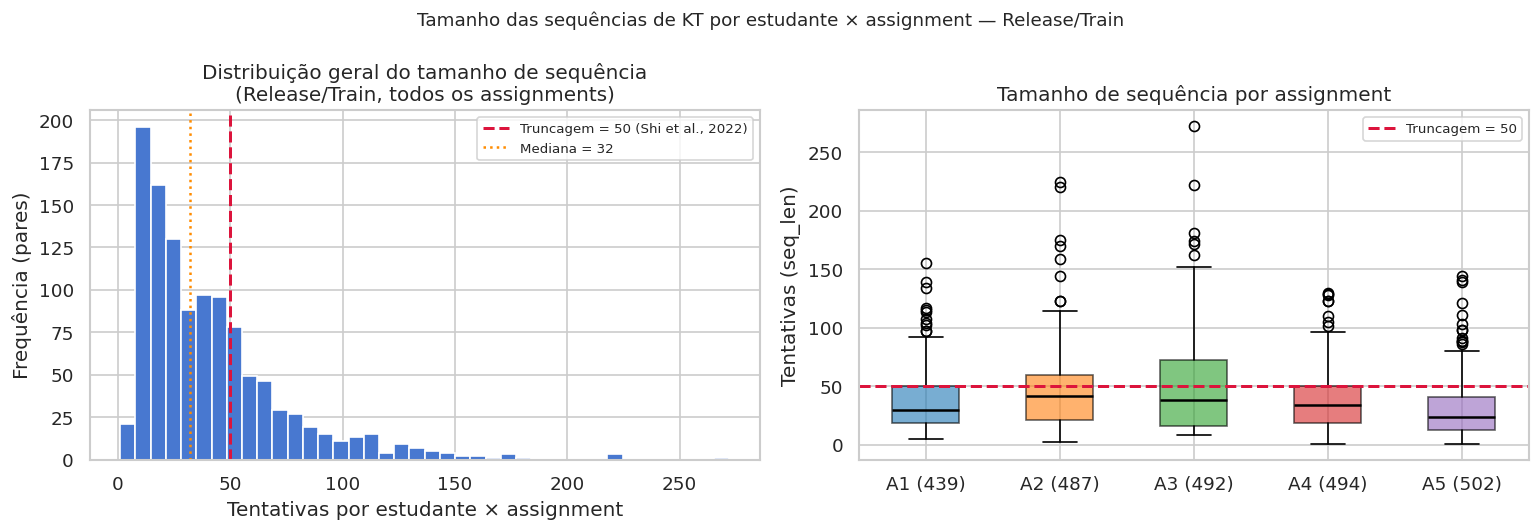

Plot salvo: results/sec4_sequence_distribution.png

=== Estudantes afetados pela truncagem por assignment ===


,Estudantes,seq_len > 50,% afetados,Mediana,P95,Máx
Assignment,,,,,,
A1 (439),233,56,24.0%,30,88,155
A2 (487),224,81,36.2%,42,110,224
A3 (492),234,92,39.3%,38,135,272
A4 (494),221,54,24.4%,34,91,130
A5 (502),222,38,17.1%,24,88,144


In [32]:
TRUNC_LIMIT = 50  # Shi et al. (2022): últimas 50 tentativas

# Tamanho de sequência por estudante × assignment (Release/Train, Run.Program apenas)
seq_len = (
    runs_rel.groupby(['SubjectID', 'AssignmentID'])
    .size()
    .reset_index(name='seq_len')
)
seq_len['assign_label'] = seq_len['AssignmentID'].map(assign_name)

# ── Estatísticas descritivas ──
print('=== Distribuição de tamanho de sequência por estudante × assignment ===')
display(seq_len['seq_len'].describe(percentiles=[.25, .50, .75, .90, .95, .99]).round(1).to_frame().T)

n_above_trunc  = (seq_len['seq_len'] > TRUNC_LIMIT).sum()
pct_above_trunc = n_above_trunc / len(seq_len) * 100
n_students_above = (
    seq_len[seq_len['seq_len'] > TRUNC_LIMIT]['SubjectID'].nunique()
)
total_students = seq_len['SubjectID'].nunique()
pct_students_above = n_students_above / total_students * 100

print(f'\nLimite de truncagem (Shi et al., 2022): {TRUNC_LIMIT} tentativas')
print(f'Pares (estudante, assignment) com seq_len > {TRUNC_LIMIT}: '
      f'{n_above_trunc} de {len(seq_len)} ({pct_above_trunc:.1f}%)')
print(f'Estudantes com ≥ 1 assignment afetado pela truncagem: '
      f'{n_students_above} de {total_students} ({pct_students_above:.1f}%)')

# ── Plot: histograma geral + boxplot por assignment ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax0 = axes[0]
ax0.hist(seq_len['seq_len'], bins=40, color=sns.color_palette('muted')[0], edgecolor='white')
ax0.axvline(TRUNC_LIMIT, color='crimson', linestyle='--', linewidth=1.8,
            label=f'Truncagem = {TRUNC_LIMIT} (Shi et al., 2022)')
ax0.axvline(seq_len['seq_len'].median(), color='darkorange', linestyle=':', linewidth=1.5,
            label=f'Mediana = {seq_len["seq_len"].median():.0f}')
ax0.set_xlabel('Tentativas por estudante × assignment')
ax0.set_ylabel('Frequência (pares)')
ax0.set_title('Distribuição geral do tamanho de sequência\n(Release/Train, todos os assignments)')
ax0.legend(fontsize=8)

ax1 = axes[1]
order_labels = [assign_name[aid] for aid in assignment_order]
data_by_assign = [
    seq_len[seq_len['AssignmentID'] == aid]['seq_len'].values
    for aid in assignment_order
]
bp = ax1.boxplot(data_by_assign, tick_labels=order_labels, patch_artist=True,
                 medianprops=dict(color='black', linewidth=1.5))
colors_box = sns.color_palette('tab10', len(assignment_order))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax1.axhline(TRUNC_LIMIT, color='crimson', linestyle='--', linewidth=1.8,
            label=f'Truncagem = {TRUNC_LIMIT}')
ax1.set_ylabel('Tentativas (seq_len)')
ax1.set_title('Tamanho de sequência por assignment')
ax1.legend(fontsize=8)

plt.suptitle('Tamanho das sequências de KT por estudante × assignment — Release/Train', fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec4_sequence_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec4_sequence_distribution.png')

# ── Percentual de estudantes afetados por assignment ──
print('\n=== Estudantes afetados pela truncagem por assignment ===')
trunc_rows = []
for aid in assignment_order:
    sub = seq_len[seq_len['AssignmentID'] == aid]
    n_aff = (sub['seq_len'] > TRUNC_LIMIT).sum()
    pct_aff = n_aff / len(sub) * 100
    trunc_rows.append({
        'Assignment': assign_name[aid],
        'Estudantes': len(sub),
        f'seq_len > {TRUNC_LIMIT}': n_aff,
        f'% afetados': f'{pct_aff:.1f}%',
        'Mediana': f'{sub["seq_len"].median():.0f}',
        'P95': f'{sub["seq_len"].quantile(0.95):.0f}',
        'Máx': f'{sub["seq_len"].max()}',
    })
display(pd.DataFrame(trunc_rows).set_index('Assignment'))

**Achado:** A distribuição de tamanho de sequência (Release/Train, Run.Program) é assimétrica à direita: mediana = 32 tentativas, média = 41.3 (±32.9), P95 = 109.3, máximo = 272. 28.3% dos pares (estudante, assignment) têm seq_len > 50 — afetando 58.1% dos estudantes (143 de 246) em ao menos um assignment. Por assignment, A3 (o mais difícil) é o mais afetado: 39.3% dos estudantes ultrapassam 50 tentativas (mediana 38, max 272). A5 (o mais fácil) tem a menor taxa de afetados: 17.1% (mediana 24).  
**Implicação para modelagem:** A truncagem em 50 tentativas (Shi et al., 2022) é conservadora para a maioria dos estudantes — a mediana global está em 32, abaixo do limite. Para os 28.3% de pares afetados, descartar as tentativas mais antigas preserva o estado de habilidade mais recente do estudante, que é o mais informativo para prever a próxima tentativa. A decisão de Shi et al. (2022) é reproduzida sem modificação. Os plots estão salvos em `results/sec4_sequence_distribution.png`.

---

## 5 — Análise do Score e Desbalanceamento

**Contexto:** O CSEDM usa Score contínuo [0, 1] para cada `Run.Program`: a fração de testes automatizados que passaram. Para Knowledge Tracing binário, adota-se o threshold `Score == 1.0` ("passou todos os testes") como `correct = 1`. Isso levanta duas questões: (1) qual a prevalência de scores parciais (0 < Score < 1) e o que se perde ao binarizar? (2) o dataset é desbalanceado — com ~76% de tentativas incorretas, acurácia seria enganosa, o que justifica AUC como métrica primária.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

### 5.1 — Distribuição do Score e Scores Parciais

**Contexto:** Os testes automatizados do CSEDM geram scores contínuos (fração de casos passados). Ao converter para label binário, descartamos a informação de "parcialmente correto". Quantificar esses scores parciais documenta a perda de granularidade e valida a escolha do threshold.  
**Hipótese:** A distribuição deve ser bimodal, concentrada em 0 e 1, com ~34–37% de scores parciais (conforme estimativa do CLAUDE.md); os valores parciais devem ser racionais simples (frações de testes passados).  
**Referência:** Price et al. (2020); Shi et al. (2022).

Total de execuções (Run.Program, Release/Train): 46,825
  Score = 0.0  (falhou todos os testes): 19,802 (42.3%)
  Score = 1.0  (passou todos os testes): 11,098 (23.7%)
  0 < Score < 1 (parcial):               15,925 (34.0%)
  Valores únicos de Score: 200

Top 10 valores de score parcial (0 < Score < 1):


,Score,n,pct
0,0.272727,442,0.94
1,0.500000,420,0.90
2,0.857143,363,0.78
3,0.307692,351,0.75
4,0.600000,334,0.71
5,0.761905,291,0.62
6,0.666667,291,0.62
7,0.750000,281,0.60
8,0.714286,279,0.60
9,0.545455,276,0.59


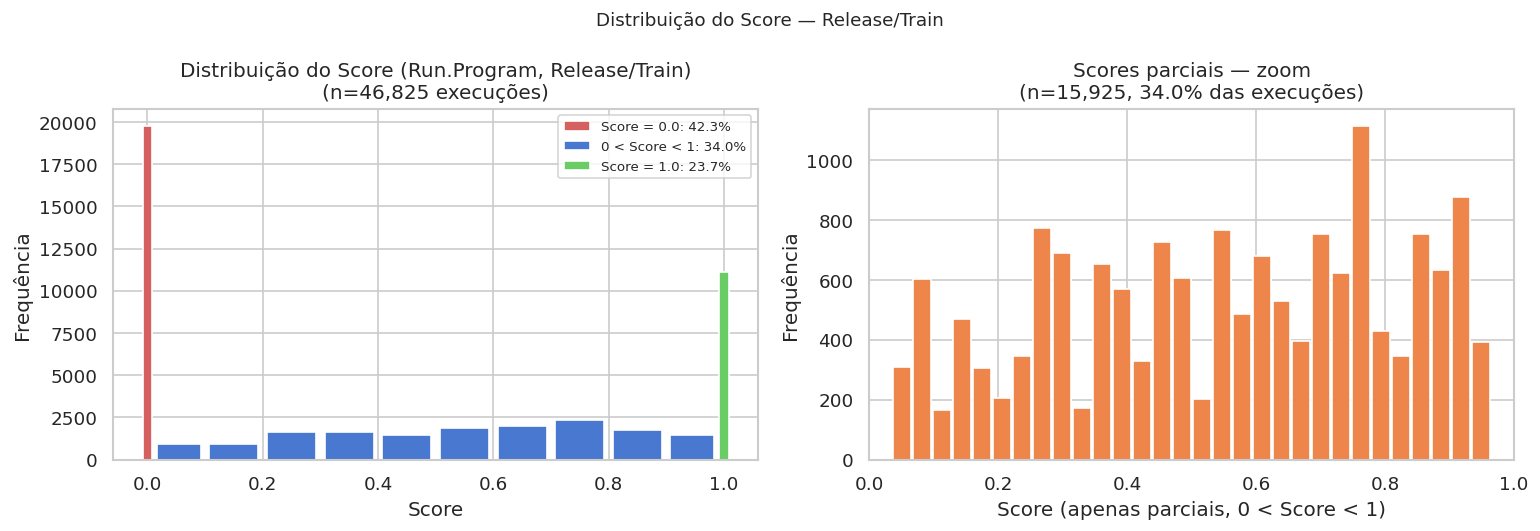

Plot salvo: results/sec5_score_distribution.png


In [33]:
from matplotlib.patches import Patch

# ── Distribuição do Score (Release/Train, Run.Program) ──
all_scores  = runs_rel['Score'].dropna()
partial_sc  = all_scores[(all_scores > 0) & (all_scores < 1)]

n_total    = len(all_scores)
n_zero     = (all_scores == 0.0).sum()
n_one      = (all_scores == 1.0).sum()
n_partial  = len(partial_sc)

pct_zero    = n_zero    / n_total * 100
pct_one     = n_one     / n_total * 100
pct_partial = n_partial / n_total * 100

print(f'Total de execuções (Run.Program, Release/Train): {n_total:,}')
print(f'  Score = 0.0  (falhou todos os testes): {n_zero:,} ({pct_zero:.1f}%)')
print(f'  Score = 1.0  (passou todos os testes): {n_one:,} ({pct_one:.1f}%)')
print(f'  0 < Score < 1 (parcial):               {n_partial:,} ({pct_partial:.1f}%)')
print(f'  Valores únicos de Score: {all_scores.nunique()}')

# ── Top valores de score parcial ──
print('\nTop 10 valores de score parcial (0 < Score < 1):')
display(
    partial_sc.value_counts().head(10)
    .rename_axis('Score').reset_index(name='n')
    .assign(pct=lambda d: (d['n'] / n_total * 100).round(2))
)

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pal = sns.color_palette('muted')

# Histograma geral — bins alinhados com 0 e 1 como categorias discretas
ax0 = axes[0]
bins = [-0.01, 0.01] + [i / 10 for i in range(1, 10)] + [0.99, 1.01]
counts, _, patches = ax0.hist(
    all_scores, bins=bins, color=pal[0], edgecolor='white', rwidth=0.85
)
patches[0].set_facecolor(pal[3])   # Score = 0 → vermelho
patches[-1].set_facecolor(pal[2])  # Score = 1 → verde
ax0.set_xlabel('Score')
ax0.set_ylabel('Frequência')
ax0.set_title(
    f'Distribuição do Score (Run.Program, Release/Train)\n'
    f'(n={n_total:,} execuções)'
)
legend_els = [
    Patch(facecolor=pal[3], label=f'Score = 0.0: {pct_zero:.1f}%'),
    Patch(facecolor=pal[0], label=f'0 < Score < 1: {pct_partial:.1f}%'),
    Patch(facecolor=pal[2], label=f'Score = 1.0: {pct_one:.1f}%'),
]
ax0.legend(handles=legend_els, fontsize=8)

# Zoom nos scores parciais
ax1 = axes[1]
ax1.hist(partial_sc, bins=30, color=pal[1], edgecolor='white', rwidth=0.9)
ax1.set_xlabel('Score (apenas parciais, 0 < Score < 1)')
ax1.set_ylabel('Frequência')
ax1.set_title(
    f'Scores parciais — zoom\n'
    f'(n={n_partial:,}, {pct_partial:.1f}% das execuções)'
)
ax1.set_xlim(0, 1)

plt.suptitle('Distribuição do Score — Release/Train', fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec5_score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec5_score_distribution.png')

**Achado:** A distribuição do Score (Release/Train, 46.825 execuções) é trimodal: 42.3% das execuções têm Score = 0.0 (falha total); 23.7% têm Score = 1.0 (acerto pleno); 34.0% têm 0 < Score < 1 (acerto parcial, 200 valores únicos). Os scores parciais mais frequentes são frações racionais que correspondem à proporção de testes passados (e.g., 3/11 ≈ 0.27, 1/2 = 0.50, 6/7 ≈ 0.86). Esses valores confirmam que o Score reflete testes automatizados com contagem discreta de casos.  
**Implicação para modelagem:** O threshold `Score == 1.0` como `correct = 1` é justificado pela separação natural entre acerto pleno e acerto parcial. Os 34.0% de scores parciais são rotulados `correct = 0` nos modelos BKT e DKT — perdendo a granularidade do acerto parcial, mas mantendo consistência com Shi et al. (2022). Para o Code-DKT com srcML, os eventos `Compile.Error` (correct = 0) enriquecem ainda mais a classe negativa sem alterar a definição de correto.

### 5.2 — Desbalanceamento por Assignment e Justificativa da Métrica AUC

**Contexto:** Com ~76.3% de tentativas incorretas (correct = 0) vs ~23.7% corretas (correct = 1), o dataset apresenta desbalanceamento moderado (~3:1). Acurácia seria inflada pela classe majoritária — um modelo que prevê sempre "incorreto" atingiria 76.3% de acurácia sem nenhum poder preditivo. AUC (Area Under the ROC Curve) mede a capacidade discriminativa independentemente do threshold de decisão e é a métrica padrão na literatura de KT.  
**Hipótese:** A razão de desbalanceamento global deve ser ~3.2:1 (76.3% incorretos / 23.7% corretos); A3 deve ter o maior imbalance (menor taxa de acerto, conforme Seção 3) e A5 o menor.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

,Total,Corretos (n),Incorretos (n),% correto,Imbalance ratio
Assignment,,,,,
A1 (439),"8,761","2,389","6,372",27.27%,2.67:1
A2 (487),"10,539","2,141","8,398",20.32%,3.92:1
A3 (492),"11,977","2,284","9,693",19.07%,4.24:1
A4 (494),"8,585","2,167","6,418",25.24%,2.96:1
A5 (502),"6,963","2,117","4,846",30.40%,2.29:1
— Global —,"46,825","11,098","35,727",23.70%,3.22:1


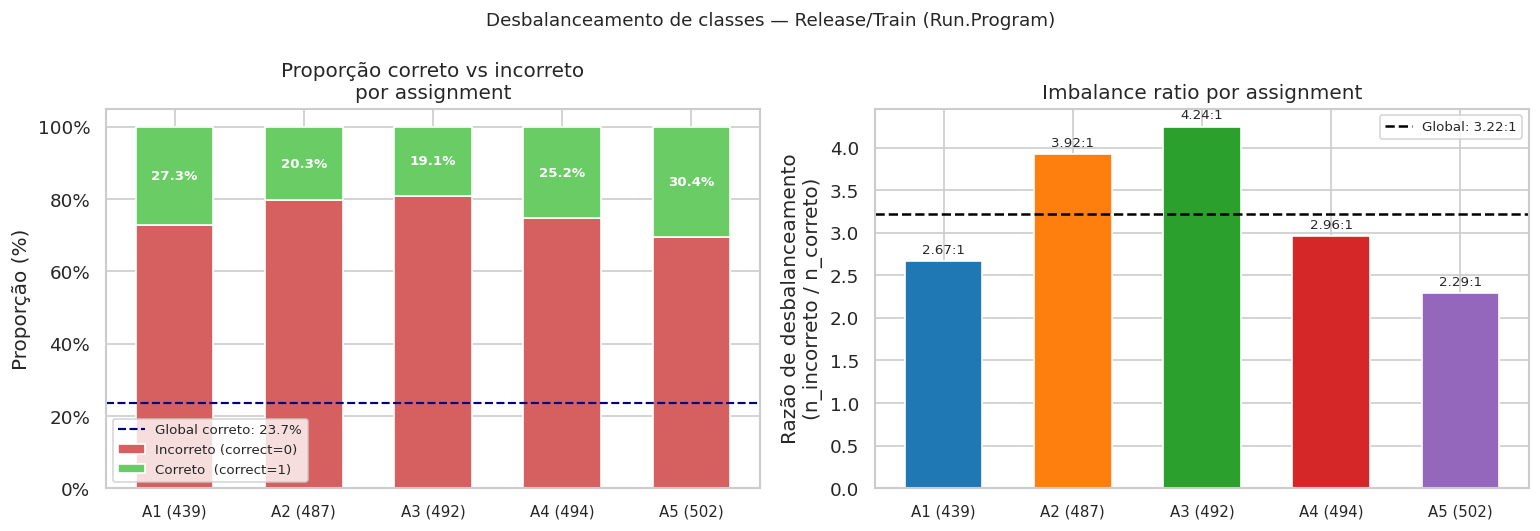

Plot salvo: results/sec5_imbalance.png


In [34]:
# ── Imbalance ratio por assignment ──
imb_rows = []
for aid in assignment_order:
    g         = runs_rel[runs_rel['AssignmentID'] == aid]
    n_corr    = g['correct'].sum()
    n_incorr  = len(g) - n_corr
    pct_corr  = n_corr / len(g) * 100
    imb_ratio = n_incorr / n_corr if n_corr > 0 else float('inf')
    imb_rows.append({
        'Assignment':         assign_name[aid],
        'Total':              f'{len(g):,}',
        'Corretos (n)':       f'{n_corr:,}',
        'Incorretos (n)':     f'{n_incorr:,}',
        '% correto':          f'{pct_corr:.2f}%',
        'Imbalance ratio':    f'{imb_ratio:.2f}:1',
    })

n_corr_g   = runs_rel['correct'].sum()
n_incorr_g = len(runs_rel) - n_corr_g
pct_corr_g = n_corr_g / len(runs_rel) * 100
imb_g      = n_incorr_g / n_corr_g

imb_rows.append({
    'Assignment':      '— Global —',
    'Total':           f'{len(runs_rel):,}',
    'Corretos (n)':    f'{n_corr_g:,}',
    'Incorretos (n)':  f'{n_incorr_g:,}',
    '% correto':       f'{pct_corr_g:.2f}%',
    'Imbalance ratio': f'{imb_g:.2f}:1',
})

imb_df = pd.DataFrame(imb_rows).set_index('Assignment')
display(imb_df)

# ── Plot: proporção empilhada + imbalance ratio ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pal = sns.color_palette('muted')

ax0 = axes[0]
x             = list(range(len(assignment_order)))
assign_labels = [assign_name[aid] for aid in assignment_order]
pct_c   = [runs_rel[runs_rel['AssignmentID'] == aid]['correct'].mean() * 100
           for aid in assignment_order]
pct_inc = [100 - p for p in pct_c]

bars_inc  = ax0.bar(x, pct_inc, label='Incorreto (correct=0)',
                    color=pal[3], width=0.6)
bars_corr = ax0.bar(x, pct_c,   bottom=pct_inc,
                    label='Correto  (correct=1)', color=pal[2], width=0.6)
ax0.axhline(pct_corr_g, color='navy', linestyle='--', linewidth=1.3,
            label=f'Global correto: {pct_corr_g:.1f}%')
ax0.set_xticks(x)
ax0.set_xticklabels(assign_labels, fontsize=9)
ax0.set_ylabel('Proporção (%)')
ax0.set_title('Proporção correto vs incorreto\npor assignment')
ax0.yaxis.set_major_formatter(mticker.PercentFormatter())
ax0.legend(fontsize=8)
for rect, bot, p in zip(bars_corr, pct_inc, pct_c):
    ax0.text(rect.get_x() + rect.get_width() / 2, bot + p / 2,
             f'{p:.1f}%', ha='center', va='center',
             fontsize=8, fontweight='bold', color='white')

ax1 = axes[1]
imb_vals = [
    (len(runs_rel[runs_rel['AssignmentID'] == aid]) -
     runs_rel[runs_rel['AssignmentID'] == aid]['correct'].sum()) /
    runs_rel[runs_rel['AssignmentID'] == aid]['correct'].sum()
    for aid in assignment_order
]
bars_imb = ax1.bar(x, imb_vals,
                   color=sns.color_palette('tab10', len(assignment_order)),
                   edgecolor='white', width=0.6)
ax1.axhline(imb_g, color='black', linestyle='--', linewidth=1.5,
            label=f'Global: {imb_g:.2f}:1')
ax1.set_xticks(x)
ax1.set_xticklabels(assign_labels, fontsize=9)
ax1.set_ylabel('Razão de desbalanceamento\n(n_incorreto / n_correto)')
ax1.set_title('Imbalance ratio por assignment')
ax1.legend(fontsize=8)
ax1.bar_label(bars_imb, labels=[f'{v:.2f}:1' for v in imb_vals],
              padding=3, fontsize=8)

plt.suptitle(
    'Desbalanceamento de classes — Release/Train (Run.Program)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec5_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec5_imbalance.png')

**Achado:** O dataset Release/Train apresenta desbalanceamento global de 3.22:1 (76.3% incorretos vs 23.7% corretos). Por assignment, A3 tem o maior desequilíbrio (4.24:1, 19.1% correto) e A5 o menor (2.29:1, 30.4% correto) — consistente com o ranking de dificuldade da Seção 3. Um classificador-baseline ("sempre incorreto") atingiria 76.3% de acurácia sem nenhum poder discriminativo, evidenciando que acurácia é inadequada para este problema.  
**Implicação para modelagem:** AUC é a métrica primária adotada neste trabalho, seguindo Shi et al. (2022) e o survey de KT (Abdelrahman et al., 2022). AUC mede discriminação independentemente do threshold de decisão e não é inflada pela classe majoritária. A métrica secundária (all-attempts AUC) complementa a análise com maior estabilidade estatística, conforme protocolo do paper de referência. Os plots estão salvos em `results/sec5_score_distribution.png` e `results/sec5_imbalance.png`.

---

## 6 — Evolução do Código e Compile.Error

**Contexto:** Estudantes de programação raramente produzem código correto de imediato. Antes de obter uma execução bem-sucedida (`Run.Program`), eles acumulam múltiplos erros de compilação (`Compile.Error`) — snapshots do código em estado não-compilável. Quantificar essa proporção e a diversidade de soluções por problema revela a riqueza estrutural do dataset e fundamenta a decisão de incluir esses eventos na sequência de Knowledge Tracing via srcML.

### 6.1 — Taxa de Compile.Error por Assignment

**Contexto:** No CSEDM, `Compile.Error` são tentativas de compilação que falharam; `Run.Program` são compilações bem-sucedidas que resultaram em execução com Score. A taxa de Compile.Error (= CE / (RP + CE)) mede a proporção de tentativas não-executáveis por assignment e determina quantos eventos Code-DKT descartaria sem o suporte a código não-compilável.
**Hipótese:** Esperamos taxas de Compile.Error entre 30% e 50% (o split All registra 30.27% de CE sobre o total de três EventTypes, mas CE é mais frequente que Compile no conjunto de submissões do usuário). Assignments mais difíceis devem apresentar taxas mais elevadas (estudantes tentam mais com erros).
**Referência:** Pankiewicz, Shi & Baker (2025); Price et al. (2020).

'Assignment  Run.Program (n)  Compile.Error (n)  Total sub.  CE %\n  A1 (439)             8761              11274       20035  56.3\n  A2 (487)            10539               8957       19496  45.9\n  A3 (492)            11977               9610       21587  44.5\n  A4 (494)             8585               7011       15596  45.0\n  A5 (502)             6963               4006       10969  36.5'


Global (Release/Train): 40,858 Compile.Error / 87,683 submissões = 46.6%


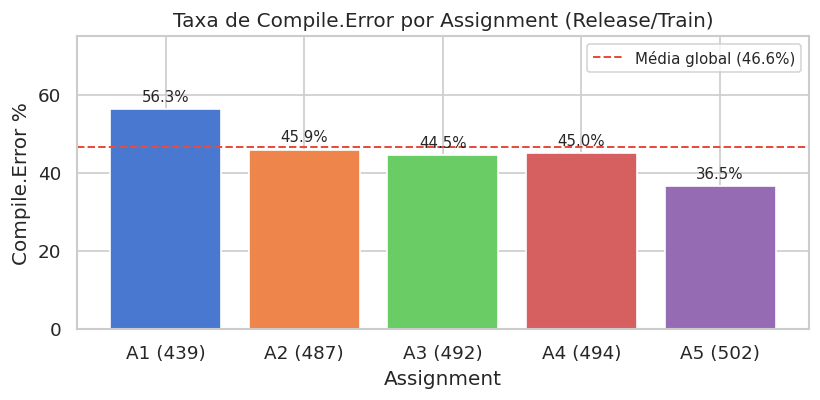

In [35]:
# ── Compile.Error rate por assignment (Release/Train) ──
compile_err_rel = rel_train_main[rel_train_main['EventType'] == 'Compile.Error'].copy()
run_prog_rel    = rel_train_main[rel_train_main['EventType'] == 'Run.Program'].copy()

ce_rows = []
for aid in assignment_order:
    n_run = (run_prog_rel['AssignmentID'] == aid).sum()
    n_ce  = (compile_err_rel['AssignmentID'] == aid).sum()
    total = n_run + n_ce
    ce_rate = n_ce / total * 100 if total > 0 else 0
    ce_rows.append({
        'Assignment':        assign_name[aid],
        'Run.Program (n)':   n_run,
        'Compile.Error (n)': n_ce,
        'Total sub.':        total,
        'CE %':              round(ce_rate, 1),
    })

ce_df = pd.DataFrame(ce_rows)
display(ce_df.to_string(index=False))

n_ce_global   = len(compile_err_rel)
n_rp_global   = len(run_prog_rel)
total_global  = n_ce_global + n_rp_global
ce_rate_global = n_ce_global / total_global * 100
print(f'\nGlobal (Release/Train): {n_ce_global:,} Compile.Error / {total_global:,} submissões = {ce_rate_global:.1f}%')

# ── Barplot ──
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = sns.color_palette('muted', len(ce_df))
bars = ax.bar(ce_df['Assignment'], ce_df['CE %'], color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in ce_df['CE %']], padding=3, fontsize=9)
ax.axhline(ce_rate_global, color='#e74c3c', linestyle='--', lw=1.2, label=f'Média global ({ce_rate_global:.1f}%)')
ax.set_xlabel('Assignment')
ax.set_ylabel('Compile.Error %')
ax.set_title('Taxa de Compile.Error por Assignment (Release/Train)')
ax.set_ylim(0, 75)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Achado:** No split Release/Train, 40.858 de 87.683 submissões são `Compile.Error` — taxa global de 46.6%. Por assignment: A1 lidera com 56.3% (11.274 CE / 20.035 sub.), seguido de A2 (45.9%), A4 (45.0%), A3 (44.5%) e A5 (36.5%). A1 apresenta taxa mais alta apesar de não ser o assignment mais difícil (Seção 3), possivelmente porque os estudantes ainda estavam adaptando o ambiente de desenvolvimento no início do semestre. A5 tem a menor taxa, sugerindo que estudantes mais experientes produzem menos erros de compilação.
**Implicação para modelagem:** Os 40.858 eventos `Compile.Error` representam 46.6% das submissões — descartá-los (como no Code-DKT original com javalang) perde quase metade do sinal de aprendizado. Incluí-los como `correct=0` na sequência KT, com features srcML, é a motivação central do srcML-DKT (Pankiewicz, Shi & Baker, 2025): srcML parseia Java compilável e não-compilável, preservando estrutura parcial como XML.

### 6.2 — Diversidade de Soluções por Problema (CodeStateID)

**Contexto:** Cada evento no CSEDM tem um `CodeStateID` único que aponta para um snapshot do código. O número de `CodeStateID` distintos por problema mede a diversidade de abordagens dos estudantes — quanto maior, mais variadas são as soluções tentadas. Alta diversidade motiva o uso de representações de código (code paths via srcML/code2vec) em vez de simples features de texto (TF-IDF) no Code-DKT.
**Hipótese:** Esperamos alta diversidade (centenas de estados únicos por problema) refletindo as múltiplas tentativas e variações de código de 329 estudantes. Problemas mais difíceis (maior n de tentativas) devem apresentar maior diversidade.
**Referência:** Shi et al. (2022); Pankiewicz, Shi & Baker (2025).

Unique CodeStateIDs por problema (Release/Train, Run.Program + Compile.Error):


,count,mean,std,min,25%,50%,75%,max
unique_code_states,50.0,936.5,402.7,349.0,712.0,809.5,1107.2,2114.0



Top-5 problemas mais diversos:


,assign_label,ProblemID,unique_code_states
0,A2 (487),102,2114
1,A1 (439),13,1950
2,A2 (487),101,1860
3,A3 (492),40,1669
4,A3 (492),32,1614


/tmp/ipykernel_377218/2648549624.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_assign, labels=assign_order_labels, patch_artist=True,


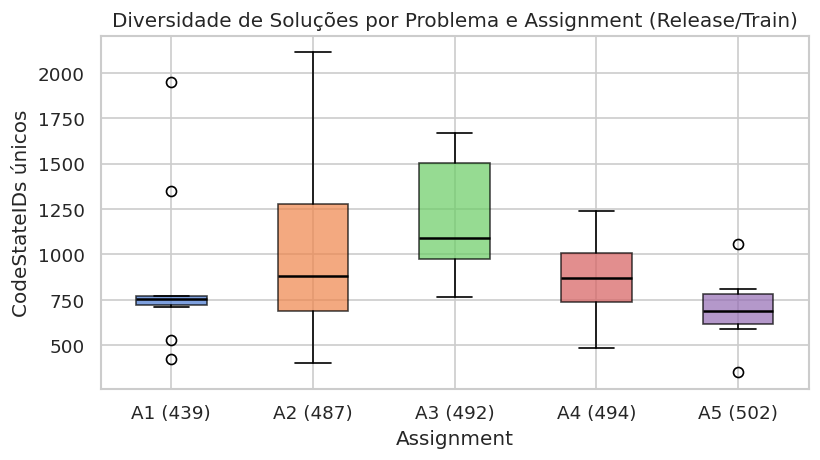


Cobertura CodeStateID: 46,825 únicos em 134,508 eventos (34.8% eventos com snapshot único)
Compile.Error: 18,563 CodeStateIDs únicos em 40,858 eventos (45.4% únicos)


In [36]:
# ── Unique CodeStateIDs por problema (Run.Program + Compile.Error, Release/Train) ──
user_events = rel_train_main[
    rel_train_main['EventType'].isin(['Run.Program', 'Compile.Error'])
].copy()
user_events = user_events[user_events['ProblemID'].notna()]

code_div = (
    user_events
    .groupby(['AssignmentID', 'ProblemID'])['CodeStateID']
    .nunique()
    .reset_index(name='unique_code_states')
)
code_div['assign_label'] = code_div['AssignmentID'].map(assign_name)

print('Unique CodeStateIDs por problema (Release/Train, Run.Program + Compile.Error):')
display(code_div['unique_code_states'].describe().rename('unique_code_states').to_frame().T.round(1))

print('\nTop-5 problemas mais diversos:')
display(code_div.nlargest(5, 'unique_code_states')[['assign_label', 'ProblemID', 'unique_code_states']]
        .reset_index(drop=True))

# ── Boxplot por assignment ──
fig, ax = plt.subplots(figsize=(7, 4))
assign_order_labels = [assign_name[a] for a in assignment_order]
data_by_assign = [
    code_div[code_div['assign_label'] == lbl]['unique_code_states'].values
    for lbl in assign_order_labels
]
bp = ax.boxplot(data_by_assign, labels=assign_order_labels, patch_artist=True,
                medianprops=dict(color='black', lw=1.5))
colors_box = sns.color_palette('muted', len(assign_order_labels))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Assignment')
ax.set_ylabel('CodeStateIDs únicos')
ax.set_title('Diversidade de Soluções por Problema e Assignment (Release/Train)')
plt.tight_layout()
plt.show()

# ── Cobertura total de CodeStateID ──
total_uniq = rel_train_main['CodeStateID'].nunique()
total_all  = len(rel_train_main)
print(f'\nCobertura CodeStateID: {total_uniq:,} únicos em {total_all:,} eventos '
      f'({total_uniq / total_all * 100:.1f}% eventos com snapshot único)')
print(f'Compile.Error: {compile_err_rel["CodeStateID"].nunique():,} CodeStateIDs únicos '
      f'em {len(compile_err_rel):,} eventos '
      f'({compile_err_rel["CodeStateID"].nunique() / len(compile_err_rel) * 100:.1f}% únicos)')

**Achado:** Cada problema do Release/Train tem em média **937 CodeStateIDs únicos** (desvio padrão = 403; mínimo = 349, máximo = 2.114). A3 tem a maior diversidade média por problema (1.198), A5 a menor (696). O problema mais diverso é o P102 (A2) com 2.114 estados únicos, seguido por P13 (A1, 1.950). Os eventos `Compile.Error` contribuem 18.563 CodeStateIDs únicos — porém, curiosamente, todos esses estados também aparecem em `Run.Program`, indicando que os snapshots de código não-compilável frequentemente coincidem com estados que outros estudantes submeteram como execução (possível reutilização de templates ou starter code). Há 100% de cobertura de `CodeStateID` em todos os eventos (sem valores ausentes).
**Implicação para modelagem:** A alta diversidade de soluções (média de 937 estados por problema) confirma que features de código capturam sinal discriminativo além do histórico de acertos/erros. O Code-DKT extrai code paths AST (via code2vec) para representar cada estado de código, e o srcML-DKT estende isso para os `Compile.Error` events — incluindo na sequência KT os ~40.858 eventos não-compiláveis com `correct=0` e features srcML (Pankiewicz, Shi & Baker, 2025).